# Phát hiện viêm phổi trên ảnh X-quang ngực

**Baseline v3 — chạy lại trên Kaggle hoặc MacBook**

Dữ liệu: [Chest X-Ray Images (Pneumonia)](https://www.kaggle.com/datasets/paultimothymooney/chest-xray-pneumonia) —
5.856 ảnh X-quang ngực của trẻ 1–5 tuổi, hai lớp `NORMAL` và `PNEUMONIA`.

---

## Tóm tắt

| Hạng mục | Lựa chọn |
|---|---|
| Kiến trúc so sánh | ResNet18, DenseNet121, CNN nhỏ train từ đầu |
| Xử lý mất cân bằng | So sánh cross-entropy có và không có trọng số lớp |
| Chia dữ liệu | Cross-validation theo **nhóm suy từ tên file**; official test giữ kín |
| Chọn checkpoint | Theo validation AUC, không dùng test |
| Chọn cấu hình | Theo OOF group AUC, trước khi mở official test |
| Điểm làm việc | Tune riêng ngưỡng ảnh và group trên OOF validation |
| Tiền xử lý | Grayscale + letterbox giữ tỉ lệ ảnh, không kéo méo thành hình vuông |
| Đơn vị đánh giá | Báo cả **mức ảnh** và **mức filename-derived group** |

Kết quả ở phần 3, diễn giải ở phần 4, hạn chế ở phần 5.

---

### Chuẩn bị

**Kaggle:** Add Data `chest-xray-pneumonia`, bật GPU T4 và Internet. `RUN_MODE="auto"`
sẽ dùng cấu hình đầy đủ. Chạy smoke trước bằng cách đổi thành `RUN_MODE="smoke"`.

**MacBook:** mở notebook từ project này; dữ liệu sibling `../chest_xray` được tự
tìm. `auto` dùng MPS/CPU và chạy smoke: 1 mô hình nhỏ × 1 fold × 1 epoch. Có thể
đặt `RUN_MODE="full"`, nhưng full 6 × 5 nên ưu tiên Kaggle GPU.

> Kết quả của notebook v2 được giữ nguyên làm audit artifact. Notebook source này
> không dùng lại output cũ; mọi bảng được sinh lại từ đầu.

## Cấu hình

In [1]:
RUN_MODE      = "auto"   # auto | smoke | full
DATA_ROOT_OVERRIDE = None # ví dụ: "/Users/me/data/chest_xray"
SEED          = 42
IMG_SIZE      = 224
BATCH_SIZE    = 32
EPOCHS        = 15
LR            = 1e-4
WEIGHT_DECAY  = 1e-5
PATIENCE      = 5
NUM_WORKERS   = 2         # runtime sẽ ép về 0 trên macOS

N_FOLDS       = 5         # 1 = một holdout 15%; 5 = cross-validation đầy đủ
VAL_FRACTION  = 0.15      # chỉ dùng khi N_FOLDS = 1
BORDER_FRAC   = 0.15      # dùng ở phần 4.3
DETERMINISTIC = True      # cudnn tất định; chậm hơn một chút, đổi lại tái lập tốt hơn
RESIZE_MODE   = "letterbox"  # giữ tỉ lệ ảnh; "stretch" chỉ để tái hiện v2
THRESHOLD_OBJECTIVE = "sensitivity"  # sensitivity | balanced_accuracy
TARGET_SENSITIVITY = 0.97

# Hai bộ augmentation. "mạnh" mô phỏng thiết lập của các cài đặt công khai
# đạt độ đặc hiệu cao hơn: xoay 30 độ, zoom và dịch ảnh.
AUG_PRESETS = {
    "nhe":  {"rotation": 10, "scale": 0.00, "translate": 0.00, "jitter": 0.15},
    "manh": {"rotation": 30, "scale": 0.20, "translate": 0.10, "jitter": 0.20},
}

# Năm dòng đầu là ablation quanh baseline. cnn_tu_dau là cấu hình tham chiếu
# thay đổi nhiều yếu tố cùng lúc, nên không dùng để kết luận riêng về pretraining.
ALL_EXPERIMENTS = [
    {"name": "resnet18",     "arch": "resnet18",    "size": 224, "aug": "nhe",
     "balancing": "weighted", "hoi": "baseline"},
    {"name": "khong_weight", "arch": "resnet18",    "size": 224, "aug": "nhe",
     "balancing": "none",     "hoi": "trọng số lớp có cần không?"},
    {"name": "augment_manh", "arch": "resnet18",    "size": 224, "aug": "manh",
     "balancing": "weighted", "hoi": "augment mạnh có tăng độ đặc hiệu?"},
    {"name": "anh_128",      "arch": "resnet18",    "size": 128, "aug": "nhe",
     "balancing": "weighted", "hoi": "128px có mất gì so với 224px?"},
    {"name": "densenet121",  "arch": "densenet121", "size": 224, "aug": "nhe",
     "balancing": "weighted", "hoi": "mô hình lớn hơn có hơn không?"},
    {"name": "cnn_tu_dau",   "arch": "small_cnn",   "size": 150, "aug": "manh",
     "balancing": "none",     "hoi": "tái hiện CNN 150px train từ đầu"},
]

SMOKE_EXPERIMENT = {
    "name": "smoke_cnn", "arch": "small_cnn", "size": 128, "aug": "nhe",
    "balancing": "weighted", "hoi": "kiểm tra pipeline, không dùng để báo cáo"
}
EXPERIMENTS = ALL_EXPERIMENTS
CLASSES = ("NORMAL", "PNEUMONIA")  # NORMAL=0, PNEUMONIA=1

In [2]:
import gc, hashlib, json, os, platform, random, re, time, warnings
from collections import Counter, defaultdict
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import PIL
import sklearn
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
from PIL import Image
from sklearn.metrics import (average_precision_score, confusion_matrix, f1_score,
                             precision_score, recall_score, roc_auc_score)
from sklearn.model_selection import StratifiedGroupKFold
from torch.utils.data import DataLoader, Dataset
from torchvision import models, transforms

warnings.filterwarnings("ignore", category=UserWarning)

IS_KAGGLE = Path("/kaggle/working").is_dir()
if torch.cuda.is_available():
    DEVICE = torch.device("cuda")
elif hasattr(torch.backends, "mps") and torch.backends.mps.is_available():
    DEVICE = torch.device("mps")
else:
    DEVICE = torch.device("cpu")

if RUN_MODE == "auto":
    RUN_MODE = "full" if IS_KAGGLE and DEVICE.type == "cuda" else "smoke"
if RUN_MODE not in {"smoke", "full"}:
    raise ValueError("RUN_MODE phải là 'auto', 'smoke' hoặc 'full'")

if RUN_MODE == "smoke":
    EPOCHS, N_FOLDS, BATCH_SIZE = 1, 1, min(BATCH_SIZE, 16)
    EXPERIMENTS = [SMOKE_EXPERIMENT]
else:
    EXPERIMENTS = ALL_EXPERIMENTS

if platform.system() == "Darwin":
    NUM_WORKERS = 0  # notebook + spawn không an toàn với closure worker/cache global
LOCAL_PROJECT_ROOT = next((p for p in (Path.cwd(), *Path.cwd().parents)
                           if (p / ".git").is_dir()), Path.cwd())
WORK_DIR = (Path("/kaggle/working") if IS_KAGGLE
            else LOCAL_PROJECT_ROOT / "artifacts/notebook_rerun")
WORK_DIR.mkdir(parents=True, exist_ok=True)
LOG_PATH = WORK_DIR / "train_log.txt"
LOG_PATH.write_text("", encoding="utf-8")
PIN_MEMORY = DEVICE.type == "cuda"
AMP_ENABLED = DEVICE.type == "cuda"
DEVICE_NAME = (torch.cuda.get_device_name(0) if DEVICE.type == "cuda"
               else "Apple Metal (MPS)" if DEVICE.type == "mps" else platform.processor() or "CPU")

if DETERMINISTIC and DEVICE.type == "cuda":
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


def set_seed(seed=SEED):
    """Seed mọi nguồn ngẫu nhiên mà pipeline đụng tới."""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


def loader_seed_args(seed=SEED):
    """generator + worker_init_fn cho DataLoader.

    Thiếu hai thứ này thì thứ tự xáo trộn và augmentation chạy trong worker vẫn
    ngẫu nhiên dù đã gọi set_seed — một lỗ hổng tái lập rất hay bị bỏ sót.
    """
    generator = torch.Generator()
    generator.manual_seed(seed)

    def worker_init_fn(worker_id):
        worker_seed = seed + worker_id
        random.seed(worker_seed)
        np.random.seed(worker_seed)

    return {"generator": generator, "worker_init_fn": worker_init_fn}


def log(*parts):
    """In ra màn hình, đồng thời ghi vào LOG_PATH.

    Output của notebook Kaggle có thể mất chunk khi in nhanh; file thì không.
    """
    line = " ".join(str(part) for part in parts)
    print(line)
    with open(LOG_PATH, "a", encoding="utf-8") as handle:
        handle.write(line + "\n")


set_seed()

# Ghi lại phiên bản thư viện. Thiếu nó thì con số trong báo cáo không gắn được
# với môi trường đã sinh ra chúng.
VERSIONS = {
    "python": platform.python_version(), "torch": torch.__version__,
    "torchvision": torchvision.__version__, "numpy": np.__version__,
    "pandas": pd.__version__, "scikit-learn": sklearn.__version__,
    "pillow": PIL.__version__,
}
with open(WORK_DIR / "environment.json", "w") as handle:
    json.dump({**VERSIONS, "device": str(DEVICE), "device_name": DEVICE_NAME,
               "run_mode": RUN_MODE, "seed": SEED,
               "deterministic": DETERMINISTIC}, handle, indent=2)

log("runtime:", "Kaggle" if IS_KAGGLE else "local", "| mode:", RUN_MODE)
log("device:", DEVICE, f"({DEVICE_NAME})", "| AMP:", AMP_ENABLED,
    "| workers:", NUM_WORKERS)
if RUN_MODE == "smoke":
    log("SMOKE RUN: chỉ kiểm tra pipeline; KHÔNG dùng chỉ số để báo cáo.")
log("phiên bản:", " ".join(f"{k}={v}" for k, v in VERSIONS.items()))

runtime: Kaggle | mode: full
device: cuda (Tesla T4) | AMP: True | workers: 2
phiên bản: python=3.12.13 torch=2.10.0+cu128 torchvision=0.25.0+cu128 numpy=2.0.2 pandas=2.3.3 scikit-learn=1.6.1 pillow=11.3.0


---

# 1. Dữ liệu

## 1.1. Nạp dữ liệu

Notebook tìm dữ liệu theo thứ tự: `DATA_ROOT_OVERRIDE`, biến môi trường
`CXR_DATA_ROOT`, Kaggle input, rồi các thư mục hiện tại/cha trên Mac. Nó chỉ
chấp nhận thư mục chứa trực tiếp `train/NORMAL` và `train/PNEUMONIA`.

Bên trong dataset còn hai thứ gây sai số nếu quét thư mục ngây thơ:

- cây `chest_xray/chest_xray/` lồng bên trong, **chứa bản sao của toàn bộ ảnh**
- cây `__MACOSX/` chứa file `._*.jpeg` — không phải ảnh, nhưng có đuôi `.jpeg`
  và có đủ cấu trúc `train/NORMAL` + `train/PNEUMONIA`

In [3]:
def list_images(directory):
    """Ảnh .jpeg thật, bỏ file sidecar ._* của macOS."""
    return sorted(p for p in Path(directory).glob("*.jpeg")
                  if not p.name.startswith("._"))


def find_data_root(search_paths):
    """Thư mục chứa trực tiếp train/NORMAL và train/PNEUMONIA."""
    if isinstance(search_paths, (str, Path)):
        search_paths = [search_paths]

    candidates = []
    for base in map(Path, search_paths):
        if not base.exists():
            continue
        for train_dir in base.rglob("train"):
            if "__MACOSX" in train_dir.parts:
                continue
            if (train_dir / "NORMAL").is_dir() and (train_dir / "PNEUMONIA").is_dir():
                candidates.append(train_dir.parent.resolve())

    if not candidates:
        raise FileNotFoundError(
            f"Không tìm thấy dataset dưới {[str(p) for p in search_paths]}. "
            "Kaggle: Add Data 'Chest X-Ray Images (Pneumonia)'. "
            "Mac: đặt DATA_ROOT_OVERRIDE hoặc CXR_DATA_ROOT.")

    candidates = sorted(set(candidates), key=lambda path: len(path.parts))
    for candidate in candidates:
        n = len(list_images(candidate / "train" / "NORMAL"))
        mark = "  <- dùng" if candidate == candidates[0] else "  (bản trùng, bỏ qua)"
        print(f"  {candidate}  [{n} ảnh train/NORMAL]{mark}")
    return candidates[0]


explicit_root = DATA_ROOT_OVERRIDE or os.environ.get("CXR_DATA_ROOT")
if explicit_root:
    DATA_ROOT = find_data_root([explicit_root])
else:
    cwd = Path.cwd()
    DATA_ROOT = find_data_root([
        "/kaggle/input", cwd / "chest_xray", cwd.parent / "chest_xray",
        cwd.parent.parent / "chest_xray", cwd / "data/raw",
        cwd.parent / "data/raw",
    ])
log("\nDATA_ROOT =", DATA_ROOT)

  /kaggle/input/datasets/paultimothymooney/chest-xray-pneumonia/chest_xray  [1341 ảnh train/NORMAL]  <- dùng
  /kaggle/input/datasets/paultimothymooney/chest-xray-pneumonia/chest_xray/chest_xray  [1341 ảnh train/NORMAL]  (bản trùng, bỏ qua)

DATA_ROOT = /kaggle/input/datasets/paultimothymooney/chest-xray-pneumonia/chest_xray


## 1.2. Danh sách ảnh và filename-derived group

Tên file là thông tin duy nhất để suy ra ảnh nào có thể thuộc cùng một group:

| Lớp | Dạng tên |
|---|---|
| Viêm phổi | `person1_bacteria_1.jpeg`, `person1_virus_6.jpeg` |
| Bình thường | `IM-0115-0001.jpeg`, `NORMAL2-IM-1427-0001.jpeg` |

Bộ đếm `person` **không dùng chung** giữa hai phân nhóm viêm phổi: `bacteria` và
`virus` mỗi loại chạy một dãy riêng từ 1. Khoá định danh vì vậy phải gồm cả phân
nhóm — mục 1.3.4 chứng minh bằng số.

In [4]:
PNEUMONIA_RE = re.compile(r"^person(\d+)_(bacteria|virus)_", re.IGNORECASE)
NORMAL_RE    = re.compile(r"^(?:(NORMAL\d+)-)?IM-(\d+)-", re.IGNORECASE)


def parse_group_id(filename):
    """Khoá group suy từ tên file; không khẳng định đây là clinical patient ID."""
    match = PNEUMONIA_RE.match(filename)
    if match:
        return f"pneumonia:{match.group(2).lower()}:{int(match.group(1))}"
    match = NORMAL_RE.match(filename)
    if match:
        return f"normal:{(match.group(1) or 'IM').lower()}:{int(match.group(2))}"
    raise ValueError(f"Tên file lạ, không suy ra được group: {filename}")


def build_manifest(root):
    """Một dòng cho mỗi ảnh: đường dẫn, split gốc, nhãn, filename-derived group."""
    rows = []
    for split in ("train", "val", "test"):
        for class_id, class_name in enumerate(CLASSES):
            directory = Path(root) / split / class_name
            if not directory.is_dir():
                continue
            for path in list_images(directory):
                rows.append({
                    "path": str(path.resolve()), "filename": path.name,
                    "split_original": split, "class_name": class_name,
                    "class_id": class_id, "group_id": parse_group_id(path.name)})
    if not rows:
        raise FileNotFoundError(f"Không có ảnh .jpeg nào dưới {root}")

    frame = pd.DataFrame(rows)
    frame["cache_index"] = np.arange(len(frame))   # vị trí trong cache ở mục 2.2
    return frame


manifest = build_manifest(DATA_ROOT)
log(f"{len(manifest):,} ảnh | {manifest['group_id'].nunique():,} filename-derived groups")
manifest.head(3)

5,856 ảnh | 4,097 filename-derived groups


,path,filename,split_original,class_name,class_id,group_id,cache_index
0,/kaggle/input/datasets/paultimothymooney/chest...,IM-0115-0001.jpeg,train,NORMAL,0,normal:im:115,0
1,/kaggle/input/datasets/paultimothymooney/chest...,IM-0117-0001.jpeg,train,NORMAL,0,normal:im:117,1
2,/kaggle/input/datasets/paultimothymooney/chest...,IM-0119-0001.jpeg,train,NORMAL,0,normal:im:119,2


## 1.3. Kiểm tra chất lượng dữ liệu

In [5]:
print("1.3.1  Số lượng theo split và lớp")
print("-" * 62)
print(f"{'split':<8}{'NORMAL':>9}{'PNEUMONIA':>12}{'tổng':>9}{'P/N':>7}")
for split in ("train", "val", "test"):
    subset = manifest[manifest["split_original"] == split]
    counts = subset["class_name"].value_counts()
    normal, pneumonia = int(counts.get("NORMAL", 0)), int(counts.get("PNEUMONIA", 0))
    ratio = pneumonia / normal if normal else float("nan")
    print(f"{split:<8}{normal:>9,}{pneumonia:>12,}{normal + pneumonia:>9,}{ratio:>7.2f}")
print(f"{'TỔNG':<8}{'':>9}{'':>12}{len(manifest):>9,}")

1.3.1  Số lượng theo split và lớp
--------------------------------------------------------------
split      NORMAL   PNEUMONIA     tổng    P/N
train       1,341       3,875    5,216   2.89
val             8           8       16   1.00
test          234         390      624   1.67
TỔNG                             5,856


Tập validation gốc chỉ có **16 ảnh** — quá nhỏ để chọn checkpoint, nên mục 2.1
cắt validation mới từ pool train+val.

Tỉ lệ hai lớp cũng khác nhau giữa các split: train **2,89:1** còn test **1,67:1**.
Điểm này quyết định cách đọc kết quả ở phần 3.

In [6]:
print("1.3.2  Ảnh trùng nội dung (SHA-256)")
print("-" * 62)
manifest["sha256"] = [hashlib.sha256(Path(path).read_bytes()).hexdigest()
                      for path in manifest["path"]]
by_hash = defaultdict(list)
for digest, split in zip(manifest["sha256"], manifest["split_original"]):
    by_hash[digest].append(split)

duplicates = [s for s in by_hash.values() if len(s) > 1]
cross_split = [s for s in duplicates if len(set(s)) > 1]
print(f"tổng file             : {len(manifest):,}")
print(f"hash duy nhất         : {len(by_hash):,}")
print(f"nhóm ảnh trùng        : {len(duplicates)}")
print(f"  trong đó xuyên split: {len(cross_split)}")
print()
print("Không có ảnh y hệt nằm xuyên official split." if not cross_split
      else "CẢNH BÁO: ảnh trùng xuyên official split — kết quả đánh giá bị nhiễm.")

1.3.2  Ảnh trùng nội dung (SHA-256)
--------------------------------------------------------------
tổng file             : 5,856
hash duy nhất         : 5,824
nhóm ảnh trùng        : 30
  trong đó xuyên split: 0

Không có ảnh y hệt nằm xuyên official split.


In [7]:
print("1.3.3  Định dạng, độ phân giải, tỉ lệ khung")
print("-" * 62)
modes, unreadable, dims = Counter(), 0, []
for path in manifest["path"]:
    try:
        with Image.open(path) as image:
            modes[image.mode] += 1
            dims.append(image.size)
    except OSError:
        unreadable += 1

dims = pd.DataFrame(dims, columns=["width", "height"])
dims["aspect"] = dims["width"] / dims["height"]
manifest[["width", "height", "aspect"]] = dims[["width", "height", "aspect"]]
manifest_dims = dims                       # dùng lại ở mục 1.4

print(f"file không mở được : {unreadable}")
for mode, count in modes.most_common():
    print(f"  mode {mode:<4}       : {count:,}")
print(f"số kích thước khác : {dims.drop(columns='aspect').drop_duplicates().shape[0]:,}")
print(f"rộng  : {dims.width.min():,} – {dims.width.max():,}  (trung vị {int(dims.width.median()):,})")
print(f"cao   : {dims.height.min():,} – {dims.height.max():,}  (trung vị {int(dims.height.median()):,})")
print(f"tỉ lệ : {dims.aspect.min():.2f} – {dims.aspect.max():.2f}  (trung vị {dims.aspect.median():.2f})")
print()
print("Tỉ lệ khung trung vị theo official split/lớp:")
display(manifest.pivot_table(index="split_original", columns="class_name",
                             values="aspect", aggfunc="median").round(3))
print("\nPipeline ép grayscale nhưng dùng letterbox để không kéo méo tỉ lệ khung.")

1.3.3  Định dạng, độ phân giải, tỉ lệ khung
--------------------------------------------------------------
file không mở được : 0
  mode L          : 5,573
  mode RGB        : 283
số kích thước khác : 4,803
rộng  : 384 – 2,916  (trung vị 1,281)
cao   : 127 – 2,713  (trung vị 888)
tỉ lệ : 0.84 – 3.38  (trung vị 1.42)

Tỉ lệ khung trung vị theo official split/lớp:


class_name,NORMAL,PNEUMONIA
split_original,,
test,1.353,1.506
train,1.223,1.488
val,1.225,1.503



Pipeline ép grayscale nhưng dùng letterbox để không kéo méo tỉ lệ khung.


In [8]:
print("1.3.4  Filename-derived group và nguy cơ trùng giữa các split")
print("-" * 62)
naive_re = re.compile(r"^(person\d+)_", re.IGNORECASE)
naive, corrected = defaultdict(set), defaultdict(set)
for filename, split in zip(manifest["filename"], manifest["split_original"]):
    match = naive_re.match(filename)
    naive[match.group(1).lower() if match else filename].add(split)
    corrected[parse_group_id(filename)].add(split)

naive_span     = sum(1 for s in naive.values() if len(s) > 1)
corrected_span = sum(1 for s in corrected.values() if len(s) > 1)
print(f"khoá person<N>              : {len(naive):,} nhóm, {naive_span} nằm ở >1 split")
print(f"khoá (phân nhóm, person<N>) : {len(corrected):,} nhóm, {corrected_span} nằm ở >1 split")

subtype_ids = defaultdict(set)
for filename in manifest["filename"]:
    match = PNEUMONIA_RE.match(filename)
    if match:
        subtype_ids[match.group(2).lower()].add(int(match.group(1)))
print()
for subtype, ids in sorted(subtype_ids.items()):
    print(f"  {subtype:<9}: {len(ids):,} số, dải 1..{max(ids)}, "
          f"mật độ {len(ids) / max(ids):.3f}")
print(f"  số được dùng bởi CẢ HAI phân nhóm: "
      f"{len(subtype_ids['bacteria'] & subtype_ids['virus']):,}")

per_group = Counter(parse_group_id(f) for f in manifest["filename"])
multi = sum(1 for n in per_group.values() if n > 1)
print(f"\nnhóm có >1 ảnh: {multi:,}/{len(per_group):,} "
      f"(nhiều nhất {max(per_group.values())} ảnh)")

1.3.4  Filename-derived group và nguy cơ trùng giữa các split
--------------------------------------------------------------
khoá person<N>              : 3,257 nhóm, 170 nằm ở >1 split
khoá (phân nhóm, person<N>) : 4,097 nhóm, 0 nằm ở >1 split

  bacteria : 1,437 số, dải 1..1954, mật độ 0.735
  virus    : 1,216 số, dải 1..1685, mật độ 0.722
  số được dùng bởi CẢ HAI phân nhóm: 979

nhóm có >1 ảnh: 726/4,097 (nhiều nhất 30 ảnh)


Hai dãy `bacteria` và `virus` đều gần liên tục, đều bắt đầu từ 1, và có 979 số
dùng ở cả hai. Nếu bộ đếm là toàn cục thì dãy `virus` phải tránh các số đã thuộc
`bacteria`; thực tế chúng trùng nhau liên tục. Vậy `person1_bacteria` và
`person1_virus` là hai người khác nhau.

Với khoá này, **không group nào nằm ở nhiều hơn một split gốc** — tập test
gốc dùng làm holdout được.

Nhưng 726 group có nhiều hơn một ảnh. Vì vậy validation phải chia theo group và
đánh giá phải báo thêm mức group. Không gọi đây là clinical patient khi chưa có
metadata chính thức.

## 1.4. Phân tích khám phá

In [9]:
C_NORMAL, C_PNEUMONIA = "#2a78d6", "#eb6834"
CLASS_COLOR = {"NORMAL": C_NORMAL, "PNEUMONIA": C_PNEUMONIA}
INK, INK_SOFT, GRID = "#0b0b0b", "#52514e", "#e5e4e0"

plt.rcParams.update({
    "figure.facecolor": "white", "axes.facecolor": "white",
    "axes.edgecolor": GRID, "axes.labelcolor": INK_SOFT,
    "axes.titlecolor": INK, "axes.titlesize": 12, "axes.titleweight": "600",
    "axes.titlelocation": "left", "axes.titlepad": 12,
    "axes.grid": True, "grid.color": GRID, "grid.linewidth": 0.8,
    "axes.axisbelow": True, "axes.spines.top": False, "axes.spines.right": False,
    "xtick.color": INK_SOFT, "ytick.color": INK_SOFT,
    "xtick.labelsize": 10, "ytick.labelsize": 10,
    "legend.frameon": False, "font.size": 10,
})


def tidy(ax, ygrid_only=True):
    ax.tick_params(length=0)
    ax.xaxis.grid(not ygrid_only)
    ax.yaxis.grid(ygrid_only)
    return ax

### Phân bố lớp theo split

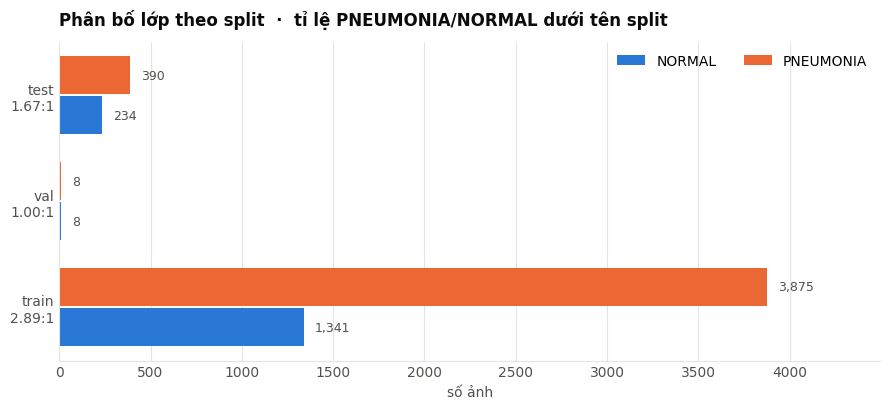

In [10]:
counts = (manifest.groupby(["split_original", "class_name"])
          .size().unstack(fill_value=0).reindex(["train", "val", "test"]))

fig, ax = plt.subplots(figsize=(9, 4.2))
y, h, gap = np.arange(len(counts)), 0.36, 0.02
for offset, cls in ((-h / 2 - gap / 2, "NORMAL"), (h / 2 + gap / 2, "PNEUMONIA")):
    bars = ax.barh(y + offset, counts[cls].values, height=h,
                   color=CLASS_COLOR[cls], label=cls)
    for rect, value in zip(bars, counts[cls].values):
        ax.text(rect.get_width() + 60, rect.get_y() + rect.get_height() / 2,
                f"{value:,}", va="center", ha="left", fontsize=9, color=INK_SOFT)

ratios = counts["PNEUMONIA"] / counts["NORMAL"].clip(lower=1)
ax.set_yticks(y)
ax.set_yticklabels([f"{s}\n{r:.2f}:1" for s, r in ratios.items()])
ax.set_xlim(0, counts.values.max() * 1.16)
ax.set_xlabel("số ảnh")
ax.set_title("Phân bố lớp theo split  ·  tỉ lệ PNEUMONIA/NORMAL dưới tên split")
ax.legend(loc="upper right", ncol=2)
tidy(ax, ygrid_only=False)
plt.tight_layout(); plt.show()

Một mô hình đoán PNEUMONIA cho mọi ảnh đã đạt **62,5%** accuracy trên test. Nên
accuracy đơn thuần không kết luận được gì.

### Kích thước và tỉ lệ khung ảnh

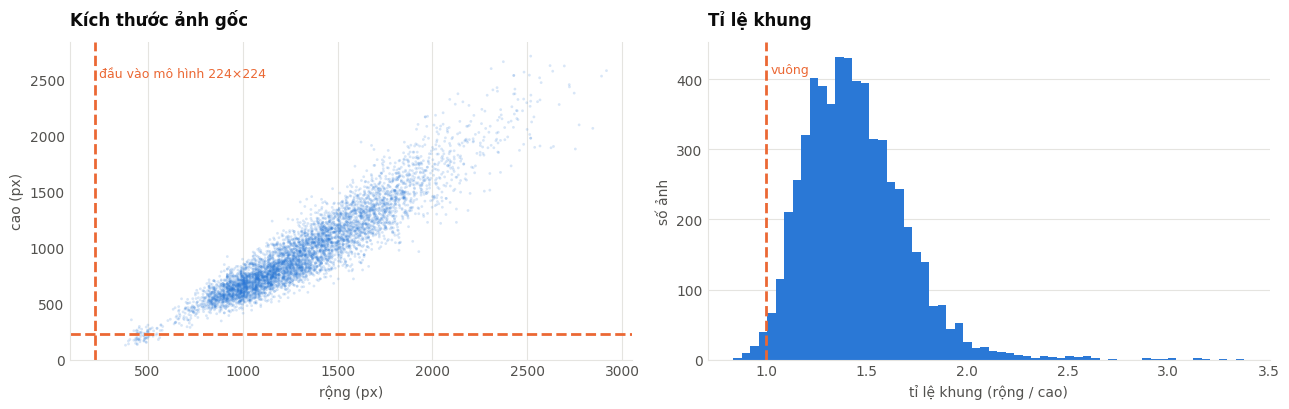

99% ảnh nằm ngang (rộng > cao).
Cache về 224×224 bằng letterbox; letterbox giữ tỉ lệ ảnh
và pad phần còn lại, áp dụng đồng nhất cho mọi split.


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.2))

axes[0].scatter(manifest_dims.width, manifest_dims.height, s=4, alpha=0.18,
                color=C_NORMAL, edgecolors="none")
axes[0].axvline(IMG_SIZE, color=C_PNEUMONIA, lw=2, ls="--")
axes[0].axhline(IMG_SIZE, color=C_PNEUMONIA, lw=2, ls="--")
axes[0].text(IMG_SIZE * 1.1, manifest_dims.height.max() * 0.93,
             f"đầu vào mô hình {IMG_SIZE}×{IMG_SIZE}", color=C_PNEUMONIA, fontsize=9)
axes[0].set_xlabel("rộng (px)"); axes[0].set_ylabel("cao (px)")
axes[0].set_title("Kích thước ảnh gốc")
tidy(axes[0], ygrid_only=False)

axes[1].hist(manifest_dims.aspect, bins=60, color=C_NORMAL)
axes[1].axvline(1.0, color=C_PNEUMONIA, lw=2, ls="--")
axes[1].text(1.02, axes[1].get_ylim()[1] * 0.9, "vuông", color=C_PNEUMONIA, fontsize=9)
axes[1].set_xlabel("tỉ lệ khung (rộng / cao)"); axes[1].set_ylabel("số ảnh")
axes[1].set_title("Tỉ lệ khung")
tidy(axes[1])

plt.tight_layout(); plt.show()

print(f"{(manifest_dims.aspect > 1).mean():.0%} ảnh nằm ngang (rộng > cao).")
print(f"Cache về {IMG_SIZE}×{IMG_SIZE} bằng {RESIZE_MODE}; letterbox giữ tỉ lệ ảnh")
print("và pad phần còn lại, áp dụng đồng nhất cho mọi split.")

### Ảnh mẫu

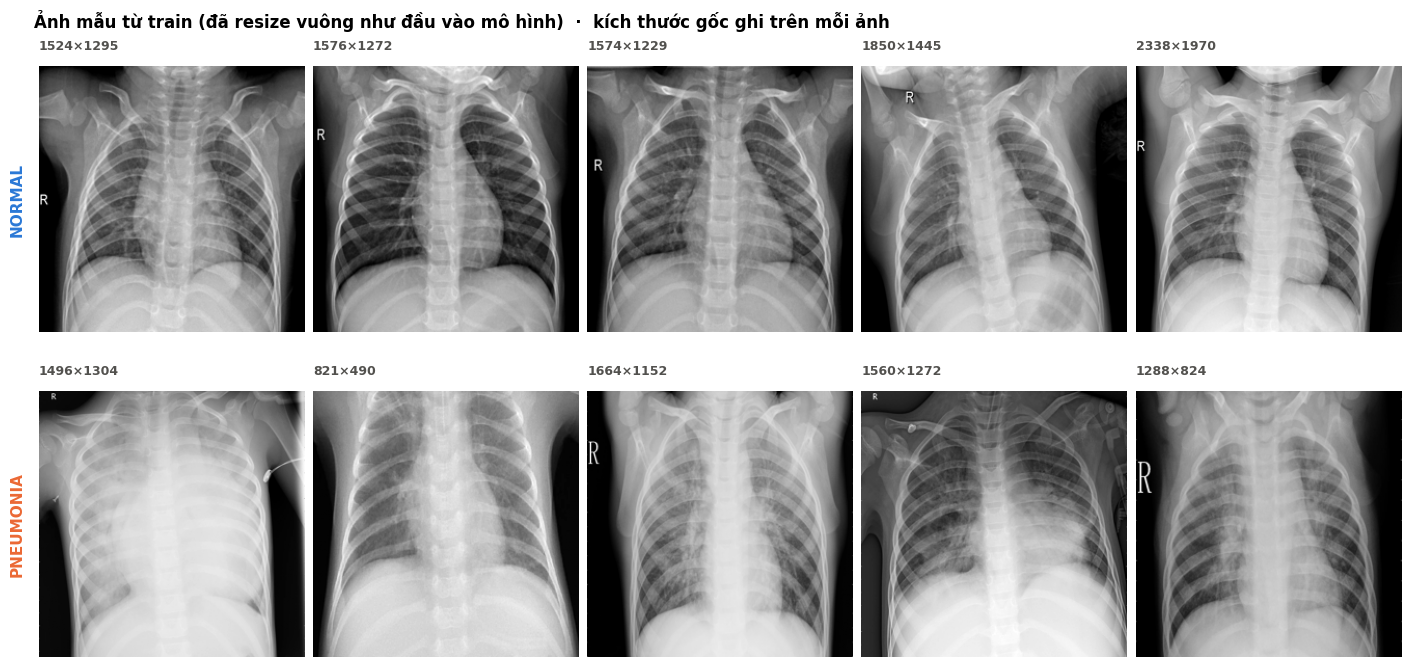

In [12]:
set_seed()
fig, axes = plt.subplots(2, 5, figsize=(14, 6.8), constrained_layout=True)
for row, cls in enumerate(CLASSES):
    pool = manifest[(manifest["split_original"] == "train")
                    & (manifest["class_name"] == cls)].sample(5, random_state=SEED)
    for col, (_, item) in enumerate(pool.iterrows()):
        with Image.open(item["path"]) as image:
            original = f"{image.size[0]}×{image.size[1]}"
            axes[row, col].imshow(image.convert("L").resize((256, 256)), cmap="gray")
        axes[row, col].set_title(original, fontsize=9, color=INK_SOFT)
        axes[row, col].axis("off")
    axes[row, 0].text(-0.08, 0.5, cls, transform=axes[row, 0].transAxes,
                      rotation=90, va="center", ha="center", fontsize=11,
                      fontweight="600", color=CLASS_COLOR[cls])
fig.suptitle("Ảnh mẫu từ train (đã resize vuông như đầu vào mô hình)  ·  "
             "kích thước gốc ghi trên mỗi ảnh",
             fontsize=12, fontweight="600", x=0.02, ha="left")
plt.show()

Viêm phổi biểu hiện là vùng mờ trắng ở nhu mô phổi. Đáng chú ý: hầu hết ảnh có
**ký hiệu định hướng "R"** ở góc trên — đặc trưng không mang thông tin bệnh lý
nhưng mô hình có thể bám vào. Phần 4 kiểm tra điều đó.

### Số ảnh trên mỗi filename-derived group

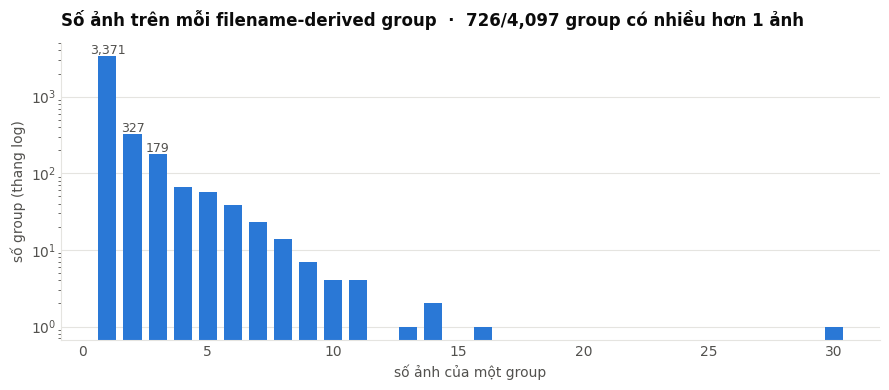

In [13]:
per_patient = manifest.groupby("group_id").size()
distribution = per_patient.value_counts().sort_index()

fig, ax = plt.subplots(figsize=(9, 4))
bars = ax.bar(distribution.index, distribution.values, color=C_NORMAL, width=0.72)
for rect, value in zip(bars, distribution.values):
    if value >= distribution.max() * 0.04:
        ax.text(rect.get_x() + rect.get_width() / 2, rect.get_height() * 1.06,
                f"{value:,}", ha="center", fontsize=9, color=INK_SOFT)
ax.set_yscale("log")
ax.set_xlabel("số ảnh của một group")
ax.set_ylabel("số group (thang log)")
ax.set_title(f"Số ảnh trên mỗi filename-derived group  ·  "
             f"{(per_patient > 1).sum():,}/{len(per_patient):,} group có nhiều hơn 1 ảnh")
tidy(ax)
plt.tight_layout(); plt.show()

### Độ sáng trung bình theo lớp

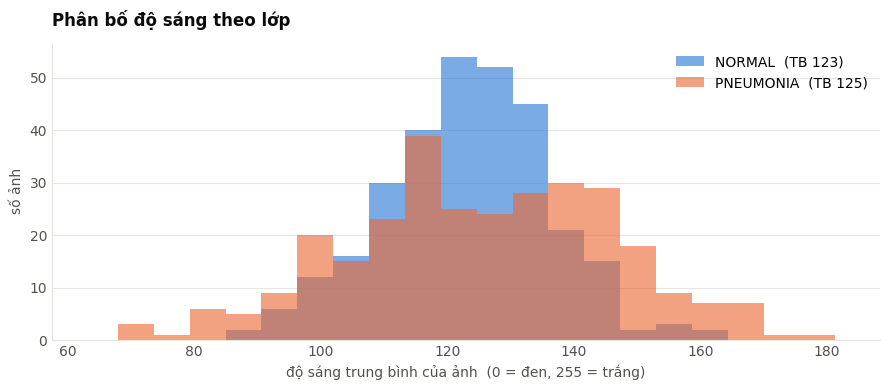

chênh lệch trung bình giữa hai lớp: 2.3 mức xám
độ lệch chuẩn trong mỗi lớp       : 16.9
Cohen's d = 0.13


In [14]:
set_seed()
train_pool = manifest[manifest["split_original"] == "train"]
sample = pd.concat([
    train_pool[train_pool["class_name"] == cls].sample(
        min(300, (train_pool["class_name"] == cls).sum()), random_state=SEED)
    for cls in CLASSES])

brightness = pd.DataFrame([
    {"class_name": item["class_name"],
     "mean": np.asarray(Image.open(item["path"]).convert("L").resize((64, 64)),
                        dtype=np.float32).mean()}
    for _, item in sample.iterrows()])

fig, ax = plt.subplots(figsize=(9, 4))
bins = np.linspace(0, 255, 46)
for cls in CLASSES:
    values = brightness[brightness["class_name"] == cls]["mean"]
    ax.hist(values, bins=bins, color=CLASS_COLOR[cls], alpha=0.62,
            label=f"{cls}  (TB {values.mean():.0f})")
span = brightness["mean"]
ax.set_xlim(max(0, span.min() - 12), min(255, span.max() + 12))
ax.set_xlabel("độ sáng trung bình của ảnh  (0 = đen, 255 = trắng)")
ax.set_ylabel("số ảnh")
ax.set_title("Phân bố độ sáng theo lớp")
ax.legend(loc="upper right")
tidy(ax)
plt.tight_layout(); plt.show()

delta = abs(brightness.groupby("class_name")["mean"].mean().diff().iloc[-1])
pooled = brightness.groupby("class_name")["mean"].std().mean()
print(f"chênh lệch trung bình giữa hai lớp: {delta:.1f} mức xám")
print(f"độ lệch chuẩn trong mỗi lớp       : {pooled:.1f}")
print(f"Cohen's d = {delta / pooled:.2f}")

Hai phân bố chồng lấn gần như hoàn toàn. Mô hình **không thể** phân biệt hai lớp
chỉ bằng độ sáng tổng thể. Kiểm tra này loại trừ một dạng học tắt; đặc trưng cục
bộ thì phải chờ phần 4.

---

# 2. Phương pháp

## 2.1. Chia dữ liệu

Tập test gốc giữ nguyên làm holdout, không tham gia bất kỳ quyết định nào.
Validation cắt từ pool train+val bằng `StratifiedGroupKFold` theo group suy từ
tên file: mọi ảnh của một group luôn nằm cùng một phía, và mỗi ảnh trong pool
làm validation đúng một lần. Đây không phải metadata bệnh nhân chính thức.

Chạy nhiều fold cho hai thứ mà một lần chia không cho được: **độ dao động** của
kết quả, và một **ngưỡng quyết định ổn định** (mục 3.4).

In [15]:
def label_split(manifest, train, val, test):
    out = manifest.copy()
    out["split"] = pd.NA
    out.loc[train.index, "split"] = "train"
    out.loc[val.index,   "split"] = "val"
    out.loc[test.index,  "split"] = "test"
    return out


def make_folds(manifest, n_folds=N_FOLDS, val_fraction=VAL_FRACTION, seed=SEED):
    """Danh sách manifest, mỗi phần tử là một fold đã gán cột split."""
    pool = manifest[manifest["split_original"].isin(["train", "val"])]
    test = manifest[manifest["split_original"] == "test"]
    n_splits = max(2, round(1 / val_fraction)) if n_folds == 1 else n_folds
    splitter = StratifiedGroupKFold(n_splits=n_splits, shuffle=True, random_state=seed)

    folds = [label_split(manifest, pool.iloc[train_idx], pool.iloc[val_idx], test)
             for train_idx, val_idx in
             splitter.split(pool, pool["class_id"], groups=pool["group_id"])]
    return folds[:1] if n_folds == 1 else folds


def count_leaked_groups(split):
    """Số filename-derived groups xuất hiện ở nhiều split. Phải bằng 0."""
    return int((split.groupby("group_id")["split"].nunique() > 1).sum())


def count_leaked_hashes(split):
    """Số nội dung ảnh y hệt xuất hiện ở nhiều split. Phải bằng 0."""
    return int((split.groupby("sha256")["split"].nunique() > 1).sum())


def split_summary(split):
    rows = []
    for name in ("train", "val", "test"):
        subset = split[split["split"] == name]
        counts = subset["class_name"].value_counts()
        normal, pneumonia = int(counts.get("NORMAL", 0)), int(counts.get("PNEUMONIA", 0))
        rows.append({"split": name, "NORMAL": normal, "PNEUMONIA": pneumonia,
                     "tổng": normal + pneumonia,
                     "groups": subset["group_id"].nunique(),
                     "P/N": round(pneumonia / max(normal, 1), 2)})
    return pd.DataFrame(rows).set_index("split")


FOLDS = make_folds(manifest)
log(f"\n{len(FOLDS)} fold, chia theo filename-derived group:")
for i, split in enumerate(FOLDS):
    s = split_summary(split)
    log(f"  fold {i}: train {s.loc['train','tổng']:>5,}  val {s.loc['val','tổng']:>4,}  "
        f"test {s.loc['test','tổng']:>4,}  |  group/hash ở >1 split: "
        f"{count_leaked_groups(split)}/{count_leaked_hashes(split)}")
    assert count_leaked_groups(split) == 0
    assert count_leaked_hashes(split) == 0
    split.to_csv(WORK_DIR / f"manifest_fold{i}.csv", index=False)

print("\nChi tiết fold 0:")
display(split_summary(FOLDS[0]))


5 fold, chia theo filename-derived group:
  fold 0: train 4,168  val 1,064  test  624  |  group/hash ở >1 split: 0/0
  fold 1: train 4,224  val 1,008  test  624  |  group/hash ở >1 split: 0/0
  fold 2: train 4,165  val 1,067  test  624  |  group/hash ở >1 split: 0/0
  fold 3: train 4,190  val 1,042  test  624  |  group/hash ở >1 split: 0/0
  fold 4: train 4,181  val 1,051  test  624  |  group/hash ở >1 split: 0/0

Chi tiết fold 0:


,NORMAL,PNEUMONIA,tổng,groups,P/N
split,,,,,
train,1092,3076,4168,2934,2.82
val,257,807,1064,735,3.14
test,234,390,624,428,1.67


## 2.2. Tiền xử lý và augmentation

Ảnh gốc trung bình khoảng 1,3 megapixel với kích thước rất khác nhau. Toàn bộ
được giải mã **một lần** về mảng `uint8` 224×224 giữ trong RAM (~294 MB).
`letterbox` giữ nguyên tỉ lệ khung rồi pad vào hình vuông; không kéo giãn giải phẫu.
Nếu
giải mã lại mỗi epoch thì CPU thành nút thắt và accelerator phải chờ.

Augmentation chỉ áp cho train. Validation và test dùng pipeline tất định — nếu
không, chỉ số đánh giá sẽ dao động theo nhiễu ngẫu nhiên.

In [16]:
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]
MEAN_T = torch.tensor(IMAGENET_MEAN, device=DEVICE).view(1, 3, 1, 1)
STD_T  = torch.tensor(IMAGENET_STD,  device=DEVICE).view(1, 3, 1, 1)


def device_augment(batch, cfg):
    """Lật, xoay, zoom, dịch, đổi sáng/tương phản trên CUDA/MPS/CPU.

    Làm bằng PIL trong DataLoader thì CPU thành nút thắt: riêng RandomRotation
    và ColorJitter đã ngốn hơn 1.000 lần thời gian đọc cache. Ở đây mọi phép
    biến đổi là tensor op chạy theo lô trên accelerator đang chọn.

    Xoay, zoom và dịch được gộp vào MỘT phép biến đổi affine, nên chỉ nội suy
    một lần thay vì ba lần chồng lên nhau.
    """
    n, dev = batch.size(0), batch.device
    flip = torch.rand(n, device=dev) < 0.5
    batch = torch.where(flip.view(-1, 1, 1, 1), batch.flip(-1), batch)

    rand = lambda: torch.rand(n, device=dev) * 2 - 1          # noqa: E731  -1..1
    angles = rand() * (cfg["rotation"] * np.pi / 180)
    zoom = 1 + rand() * cfg["scale"]
    cos, sin = torch.cos(angles) * zoom, torch.sin(angles) * zoom
    theta = torch.zeros(n, 2, 3, device=dev)
    theta[:, 0, 0], theta[:, 0, 1] = cos, -sin
    theta[:, 1, 0], theta[:, 1, 1] = sin, cos
    theta[:, 0, 2] = rand() * cfg["translate"]
    theta[:, 1, 2] = rand() * cfg["translate"]
    grid = F.affine_grid(theta, batch.shape, align_corners=False)
    batch = F.grid_sample(batch, grid, align_corners=False, padding_mode="zeros")

    j = cfg["jitter"]
    scale = 1 + rand().view(-1, 1, 1, 1) * j
    contrast = 1 + rand().view(-1, 1, 1, 1) * j
    mean = batch.mean(dim=(1, 2, 3), keepdim=True)
    return ((batch * scale - mean) * contrast + mean).clamp(0, 1)


def to_model_input(batch_uint8, size=IMG_SIZE, aug=None):
    """(B,H,W) uint8 -> (B,3,H,W) chuẩn hoá trên DEVICE.

    Cache giữ ảnh ở IMG_SIZE; thí nghiệm nào cần kích thước khác thì thu nhỏ
    ngay trên DEVICE. Đây là resize hai bước (gốc -> IMG_SIZE -> size), áp dụng
    đồng nhất cho mọi split nên không tạo chênh lệch giữa train và test.
    """
    x = batch_uint8.to(DEVICE, non_blocking=True).float().div_(255).unsqueeze(1)
    if size != IMG_SIZE:
        x = F.interpolate(x, size=(size, size), mode="bilinear", align_corners=False)
    if aug is not None:
        x = device_augment(x, aug)
    return (x.expand(-1, 3, -1, -1) - MEAN_T) / STD_T


def resize_for_cache(image, size=IMG_SIZE, mode=RESIZE_MODE):
    gray = image.convert("L")
    if mode == "stretch":
        return np.asarray(gray.resize((size, size), Image.Resampling.BILINEAR))
    if mode != "letterbox":
        raise ValueError(f"RESIZE_MODE lạ: {mode}")
    gray.thumbnail((size, size), Image.Resampling.BILINEAR)
    array = np.asarray(gray)
    fill = int(np.median(array))
    canvas = Image.new("L", (size, size), color=fill)
    offset = ((size - gray.width) // 2, (size - gray.height) // 2)
    canvas.paste(gray, offset)
    return np.asarray(canvas)


def build_image_cache(manifest, size=IMG_SIZE):
    cache = np.zeros((len(manifest), size, size), dtype=np.uint8)
    for position, path in enumerate(manifest["path"]):
        with Image.open(path) as image:
            cache[position] = resize_for_cache(image, size)
        if (position + 1) % 1500 == 0:
            print(f"  {position + 1:,}/{len(manifest):,}")
    return cache


_started = time.time()
IMAGE_CACHE = build_image_cache(manifest)
log(f"cache ({RESIZE_MODE}): {IMAGE_CACHE.nbytes / 1e6:.0f} MB cho {len(manifest):,} ảnh "
    f"trong {time.time() - _started:.0f}s")


class XRayDataset(Dataset):
    """Trả về ảnh uint8 thô; augmentation diễn ra trên DEVICE."""

    def __init__(self, rows):
        self.rows = rows

    def __len__(self):
        return len(self.rows)

    def __getitem__(self, index):
        cache_index, label = self.rows[index]
        return torch.from_numpy(IMAGE_CACHE[cache_index]), label


def make_loader(split, name, batch_size=BATCH_SIZE, seed=SEED):
    subset = split[split["split"] == name]
    return DataLoader(
        XRayDataset(list(zip(subset["cache_index"], subset["class_id"]))),
        batch_size=batch_size, shuffle=(name == "train"),
        num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY,
        persistent_workers=NUM_WORKERS > 0,
        **loader_seed_args(seed))


def make_loaders(split, batch_size=BATCH_SIZE, seed=SEED):
    return {name: make_loader(split, name, batch_size, seed)
            for name in ("train", "val")}


def class_weights_from(split):
    """Trọng số nghịch tần suất, chuẩn hoá để loss giữ nguyên thang đo."""
    counts = Counter(split[split["split"] == "train"]["class_id"])
    total = sum(counts.values())
    return torch.tensor([total / (len(CLASSES) * counts[i]) for i in range(len(CLASSES))],
                        dtype=torch.float, device=DEVICE)

  1,500/5,856
  3,000/5,856
  4,500/5,856
cache (letterbox): 294 MB cho 5,856 ảnh trong 43s


## 2.3. Chỉ số đánh giá

Bài toán y tế nên bảng kết quả gồm cả nhóm chỉ số học máy lẫn nhóm quen dùng
trong lâm sàng:

| Chỉ số | Ý nghĩa | Lưu ý khi đọc |
|---|---|---|
| `accuracy` | Tỉ lệ đúng chung | Đoán bừa PNEUMONIA đã được 62,5% trên tập test này |
| `precision` | Trong số ca bị gắn nhãn bệnh, bao nhiêu đúng | **Phụ thuộc tỉ lệ mắc bệnh** của tập đang đo |
| `recall` = độ nhạy | Trong số ca bệnh thật, bắt được bao nhiêu | Bỏ sót viêm phổi là lỗi nguy hiểm nhất |
| `specificity` = độ đặc hiệu | Trong số ca lành thật, nhận đúng bao nhiêu | Phơi bày tỉ lệ báo động giả |
| `f1` | Trung bình điều hoà precision và recall | Chỉ nhìn lớp dương |
| `bal_acc` | Trung bình độ nhạy và độ đặc hiệu | Không thưởng cho mô hình đoán lệch một phía |
| `auc` | Chất lượng xếp hạng, không phụ thuộc ngưỡng | Cao mà accuracy thấp ⇒ vấn đề ở ngưỡng |
| `pr_auc` | Như trên nhưng nhìn qua precision | |

**Về precision trong bối cảnh y tế.** Precision (giá trị tiên đoán dương) thay
đổi theo tỉ lệ mắc bệnh của quần thể: cùng một mô hình đem sang nơi có tỉ lệ mắc
khác sẽ cho precision khác, dù mô hình không đổi. Tập test ở đây có **62,5% ca
bệnh** — cao hơn thực tế phòng khám rất nhiều, nên precision đo ở đây không
chuyển sang thực tế được.

Độ nhạy và độ đặc hiệu là thuộc tính của chính mô hình, không phụ thuộc tỉ lệ
mắc. Vì vậy chúng là số chính của báo cáo này, còn precision ghi kèm chú thích.

Với một công cụ **sàng lọc**, bỏ sót ca bệnh nguy hiểm hơn báo động giả, nên độ
nhạy được ưu tiên. Precision chỉ thành ràng buộc chính khi mỗi ca dương tính kéo
theo can thiệp tốn kém hoặc xâm lấn.

**Mức ảnh và mức group.** Tập test có 624 ảnh nhưng 428 group suy từ tên file,
trong đó 82 group có nhiều hơn một ảnh. Chỉ số mức ảnh tính trọng số gấp bội cho
group có nhiều ảnh. Báo cáo cả hai, nhưng không gọi group này là bệnh nhân chính
thức vì dataset không kèm patient metadata.

In [17]:
METRIC_COLS = ["accuracy", "precision", "recall", "specificity",
               "f1", "bal_acc", "auc", "pr_auc"]


def metrics_at(labels, probs, threshold=0.5):
    """Chấm điểm tại một ngưỡng. threshold=0.5 chính là argmax trên hai logit."""
    labels, probs = np.asarray(labels), np.asarray(probs)
    preds = (probs >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(labels, preds, labels=[0, 1]).ravel()
    sensitivity, specificity = tp / max(tp + fn, 1), tn / max(tn + fp, 1)
    return {
        "threshold": float(threshold),
        "accuracy": float((labels == preds).mean()),
        "precision": precision_score(labels, preds, zero_division=0),
        "recall": recall_score(labels, preds, zero_division=0),
        "specificity": float(specificity),
        "f1": f1_score(labels, preds, zero_division=0),
        "bal_acc": float((sensitivity + specificity) / 2),
        "auc": roc_auc_score(labels, probs),
        "pr_auc": average_precision_score(labels, probs),
        "confusion_matrix": confusion_matrix(labels, preds).tolist(),
    }


def to_group_level(group_ids, labels, probs):
    """Gộp theo filename-derived group; xác suất là trung bình các ảnh."""
    frame = pd.DataFrame({"group": group_ids, "label": labels, "prob": probs})
    rolled = frame.groupby("group").agg(label=("label", "first"), prob=("prob", "mean"))
    return rolled["label"].to_numpy(), rolled["prob"].to_numpy()


def tune_threshold(labels, probs, objective=THRESHOLD_OBJECTIVE,
                   target_sensitivity=TARGET_SENSITIVITY):
    """Chọn một candidate thật trên validation/OOF, không nội suy qua vùng tie."""
    labels, probs = np.asarray(labels), np.asarray(probs)
    candidates = np.unique(np.clip(probs, 0.001, 0.999))
    if len(candidates) > 400:
        indices = np.linspace(0, len(candidates) - 1, 400).round().astype(int)
        candidates = candidates[np.unique(indices)]

    rows = [metrics_at(labels, probs, float(t)) for t in candidates]
    if objective == "balanced_accuracy":
        best = max(rows, key=lambda m: (m["bal_acc"], m["specificity"],
                                        m["recall"], m["threshold"]))
    elif objective == "sensitivity":
        feasible = [m for m in rows if m["recall"] >= target_sensitivity - 1e-12]
        if not feasible:
            warnings.warn("Không có ngưỡng đạt target sensitivity; dùng recall cao nhất.")
            feasible = rows
            best = max(feasible, key=lambda m: (m["recall"], m["specificity"],
                                                m["threshold"]))
        else:
            best = max(feasible, key=lambda m: (m["specificity"], m["bal_acc"],
                                                m["threshold"]))
    else:
        raise ValueError(f"THRESHOLD_OBJECTIVE lạ: {objective}")
    return float(best["threshold"]), best

## 2.4. Kiến trúc

Ba kiến trúc có thể chạy trong cùng framework. Chỉ các dòng ablation đổi đúng
một yếu tố mới được diễn giải nhân quả; cấu hình `small_cnn` khác nhiều yếu tố:

| Tên | Mô tả |
|---|---|
| `resnet18` | Pretrained ImageNet, fine-tune toàn bộ |
| `densenet121` | Pretrained ImageNet, sâu hơn, nhiều tham số hơn |
| `small_cnn` | 4 khối tích chập train từ đầu, không pretrained |

`small_cnn` là tham chiếu train-from-scratch, không cô lập riêng tác động của
pretraining.

In [18]:
class SmallCNN(nn.Module):
    """4 khối Conv-BN-ReLU-Pool rồi gộp toàn cục. Train từ đầu."""

    def __init__(self, num_classes=len(CLASSES)):
        super().__init__()
        def block(cin, cout):
            return nn.Sequential(
                nn.Conv2d(cin, cout, 3, padding=1), nn.BatchNorm2d(cout),
                nn.ReLU(inplace=True), nn.MaxPool2d(2))
        self.features = nn.Sequential(block(3, 32), block(32, 64),
                                      block(64, 128), block(128, 256))
        self.classifier = nn.Sequential(
            nn.AdaptiveAvgPool2d(1), nn.Flatten(),
            nn.Dropout(0.3), nn.Linear(256, num_classes))

    def forward(self, x):
        return self.classifier(self.features(x))


def build_model(arch, pretrained=True, device=DEVICE):
    if arch == "resnet18":
        weights = models.ResNet18_Weights.DEFAULT if pretrained else None
        model = models.resnet18(weights=weights)
        model.fc = nn.Linear(model.fc.in_features, len(CLASSES))
    elif arch == "densenet121":
        weights = models.DenseNet121_Weights.DEFAULT if pretrained else None
        model = models.densenet121(weights=weights)
        model.classifier = nn.Linear(model.classifier.in_features, len(CLASSES))
    elif arch == "small_cnn":
        model = SmallCNN()
    else:
        raise ValueError(f"Kiến trúc lạ: {arch!r}")
    return model.to(device)


def target_layer_for(model, arch):
    """Lớp tích chập cuối để gắn Grad-CAM. Chỉ đích danh theo kiến trúc.

    Cách dò 'Conv2d cuối cùng' sẽ sai âm thầm khi đổi kiến trúc — heatmap vẫn
    hiện ra, chỉ là hiện sai chỗ.
    """
    return {"resnet18": lambda: model.layer4[-1],
            "densenet121": lambda: model.features.denseblock4,
            "small_cnn": lambda: model.features[-1]}[arch]()


def parameter_count_millions(arch):
    model = build_model(arch, pretrained=False, device=torch.device("cpu"))
    count = sum(p.numel() for p in model.parameters()) / 1e6
    del model
    return round(count, 1)


display(pd.DataFrame([
    {"thí nghiệm": s["name"], "kiến trúc": s["arch"], "px": s["size"],
     "augment": s["aug"], "balancing": s["balancing"],
     "tham số (M)": parameter_count_millions(s["arch"]),
     "câu hỏi": s["hoi"]}
    for s in EXPERIMENTS]).set_index("thí nghiệm"))

,kiến trúc,px,augment,balancing,tham số (M),câu hỏi
thí nghiệm,,,,,,
resnet18,resnet18,224,nhe,weighted,11.2,baseline
khong_weight,resnet18,224,nhe,none,11.2,trọng số lớp có cần không?
augment_manh,resnet18,224,manh,weighted,11.2,augment mạnh có tăng độ đặc hiệu?
anh_128,resnet18,128,nhe,weighted,11.2,128px có mất gì so với 224px?
densenet121,densenet121,224,nhe,weighted,7.0,mô hình lớn hơn có hơn không?
cnn_tu_dau,small_cnn,150,manh,none,0.4,tái hiện CNN 150px train từ đầu


## 2.5. Vòng huấn luyện

Adam, learning rate giảm theo validation AUC, dừng sớm sau 5 epoch không cải
thiện. Mỗi fold chỉ sinh prediction validation và checkpoint. Sau đó notebook
ghép OOF validation để chọn cấu hình và tune hai threshold riêng. Official test
chỉ được đọc **một lần cho cấu hình đã khóa**.

In [19]:
@torch.no_grad()
def predict(model, loader, size=IMG_SIZE):
    """(nhãn thật, xác suất PNEUMONIA) trên toàn bộ loader."""
    model.eval()
    labels_all, probs_all = [], []
    for images, labels in loader:
        logits = model(to_model_input(images, size))
        probs_all += torch.softmax(logits.float(), dim=1)[:, 1].cpu().tolist()
        labels_all += labels.tolist()
    return np.array(labels_all), np.array(probs_all)


def run_fold(spec, fold_index, epochs=EPOCHS):
    log(f"\n{'=' * 62}\n{spec['name']}  |  fold {fold_index}\n{'=' * 62}")
    log(f"{spec['arch']} | {spec['size']}px | augment {spec['aug']} | "
        f"balancing {spec['balancing']}")
    set_seed(SEED + fold_index)

    split = FOLDS[fold_index]
    loaders = make_loaders(split, seed=SEED + fold_index)
    try:
        model = build_model(spec["arch"], pretrained=True)
    except Exception as exc:
        raise RuntimeError("Không tải được ImageNet weights. Bật Internet trên Kaggle "
                           "hoặc tải weights vào cache trước khi chạy.") from exc
    size, aug = spec["size"], AUG_PRESETS[spec["aug"]]

    weights = class_weights_from(split) if spec["balancing"] == "weighted" else None
    log("trọng số lớp:", [round(w, 3) for w in weights.tolist()] if weights is not None
        else "không dùng")
    criterion = nn.CrossEntropyLoss(weight=weights)
    optimizer = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode="max", factor=0.3, patience=2)
    scaler = torch.amp.GradScaler("cuda", enabled=AMP_ENABLED)

    best_score, best_epoch, best_state, stale = -np.inf, 0, None, 0
    for epoch in range(1, epochs + 1):
        model.train()
        running_loss = 0.0
        for images, labels in loaders["train"]:
            inputs = to_model_input(images, size, aug)
            labels = labels.to(DEVICE, non_blocking=PIN_MEMORY)
            optimizer.zero_grad(set_to_none=True)
            with torch.amp.autocast(device_type=DEVICE.type, enabled=AMP_ENABLED):
                loss = criterion(model(inputs), labels)
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
            running_loss += loss.item() * inputs.size(0)

        train_loss = running_loss / len(loaders["train"].dataset)
        val_labels, val_probs = predict(model, loaders["val"], size)
        val_metrics = metrics_at(val_labels, val_probs, 0.5)
        scheduler.step(val_metrics["auc"])

        marker = ""
        if val_metrics["auc"] > best_score + 1e-8:
            best_score, best_epoch, stale = val_metrics["auc"], epoch, 0
            best_state = {k: v.detach().cpu().clone()
                          for k, v in model.state_dict().items()}
            marker = "  <- best"
        else:
            stale += 1

        log(f"epoch {epoch:>2}/{epochs}  loss {train_loss:.4f}  "
            f"val_f1@0.5 {val_metrics['f1']:.4f}  val_auc {val_metrics['auc']:.4f}{marker}")
        if stale >= PATIENCE:
            log(f"dừng sớm ở epoch {epoch}")
            break

    model.load_state_dict(best_state)
    log(f"khôi phục checkpoint epoch {best_epoch}, val_auc {best_score:.4f}")
    val_labels, val_probs = predict(model, loaders["val"], size)
    val_rows = split[split["split"] == "val"].reset_index(drop=True)
    val_groups = val_rows["group_id"].to_numpy()
    assert np.array_equal(val_labels, val_rows["class_id"].to_numpy())

    tag = f"{spec['name']}_fold{fold_index}"
    checkpoint_path = WORK_DIR / f"{tag}.pth"
    torch.save(best_state, checkpoint_path)
    val_rows.assign(p_pneumonia=val_probs).to_csv(
        WORK_DIR / f"validation_predictions_{tag}.csv", index=False)

    result = {
        "experiment": spec["name"], "arch": spec["arch"], "size": spec["size"],
        "balancing": spec["balancing"], "fold": fold_index,
        "best_epoch": best_epoch, "checkpoint": str(checkpoint_path),
        "val_labels": val_labels, "val_probs": val_probs, "val_groups": val_groups,
        "val": metrics_at(val_labels, val_probs, 0.5),
    }
    del model, loaders, optimizer, scheduler, scaler, best_state
    gc.collect()
    if DEVICE.type == "cuda":
        torch.cuda.empty_cache()
    elif DEVICE.type == "mps":
        torch.mps.empty_cache()
    return result

---

# 3. Kết quả

## 3.1. Huấn luyện

In [20]:
log(f"Bắt đầu {RUN_MODE}: {len(EXPERIMENTS)} thí nghiệm × {len(FOLDS)} fold × "
    f"tối đa {EPOCHS} epoch")
_t0 = time.time()
RUNS = [run_fold(spec, fold)
        for spec in EXPERIMENTS
        for fold in range(len(FOLDS))]
log(f"\ntổng thời gian: {(time.time() - _t0) / 60:.1f} phút "
    f"({len(EXPERIMENTS)} thí nghiệm × {len(FOLDS)} fold)")

Bắt đầu full: 6 thí nghiệm × 5 fold × tối đa 15 epoch

resnet18  |  fold 0
resnet18 | 224px | augment nhe | balancing weighted
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 187MB/s]


trọng số lớp: [1.908, 0.678]
epoch  1/15  loss 0.1276  val_f1@0.5 0.9786  val_auc 0.9966  <- best
epoch  2/15  loss 0.0679  val_f1@0.5 0.9889  val_auc 0.9989  <- best
epoch  3/15  loss 0.0503  val_f1@0.5 0.9926  val_auc 0.9994  <- best
epoch  4/15  loss 0.0391  val_f1@0.5 0.9841  val_auc 0.9991
epoch  5/15  loss 0.0428  val_f1@0.5 0.9836  val_auc 0.9989
epoch  6/15  loss 0.0220  val_f1@0.5 0.9906  val_auc 0.9991
epoch  7/15  loss 0.0153  val_f1@0.5 0.9938  val_auc 0.9994
epoch  8/15  loss 0.0106  val_f1@0.5 0.9950  val_auc 0.9994  <- best
epoch  9/15  loss 0.0091  val_f1@0.5 0.9926  val_auc 0.9994
epoch 10/15  loss 0.0073  val_f1@0.5 0.9950  val_auc 0.9995  <- best
epoch 11/15  loss 0.0077  val_f1@0.5 0.9932  val_auc 0.9995
epoch 12/15  loss 0.0050  val_f1@0.5 0.9938  val_auc 0.9995  <- best
epoch 13/15  loss 0.0051  val_f1@0.5 0.9938  val_auc 0.9995
epoch 14/15  loss 0.0058  val_f1@0.5 0.9926  val_auc 0.9995  <- best
epoch 15/15  loss 0.0068  val_f1@0.5 0.9932  val_auc 0.9995  <- best

100%|██████████| 30.8M/30.8M [00:00<00:00, 134MB/s]


trọng số lớp: [1.908, 0.678]
epoch  1/15  loss 0.1384  val_f1@0.5 0.9851  val_auc 0.9968  <- best
epoch  2/15  loss 0.0661  val_f1@0.5 0.9888  val_auc 0.9984  <- best
epoch  3/15  loss 0.0452  val_f1@0.5 0.9914  val_auc 0.9987  <- best
epoch  4/15  loss 0.0447  val_f1@0.5 0.9913  val_auc 0.9982
epoch  5/15  loss 0.0274  val_f1@0.5 0.9881  val_auc 0.9984
epoch  6/15  loss 0.0186  val_f1@0.5 0.9925  val_auc 0.9992  <- best
epoch  7/15  loss 0.0253  val_f1@0.5 0.9889  val_auc 0.9985
epoch  8/15  loss 0.0163  val_f1@0.5 0.9877  val_auc 0.9991
epoch  9/15  loss 0.0115  val_f1@0.5 0.9931  val_auc 0.9995  <- best
epoch 10/15  loss 0.0171  val_f1@0.5 0.9870  val_auc 0.9982
epoch 11/15  loss 0.0216  val_f1@0.5 0.9931  val_auc 0.9995
epoch 12/15  loss 0.0162  val_f1@0.5 0.9767  val_auc 0.9971
epoch 13/15  loss 0.0092  val_f1@0.5 0.9925  val_auc 0.9995
epoch 14/15  loss 0.0065  val_f1@0.5 0.9938  val_auc 0.9995  <- best
epoch 15/15  loss 0.0047  val_f1@0.5 0.9938  val_auc 0.9995  <- best
khôi phụ

In [21]:
display(pd.DataFrame([
    {"thí nghiệm": r["experiment"], "fold": r["fold"],
     "epoch tốt nhất": r["best_epoch"], "val F1": round(r["val"]["f1"], 4),
     "val AUC": round(r["val"]["auc"], 4),
     "checkpoint": Path(r["checkpoint"]).name}
    for r in RUNS]).set_index(["thí nghiệm", "fold"]))

epoch tốt nhất  val F1  val AUC              checkpoint
thí nghiệm   fold                                                         
resnet18     0                 15  0.9932   0.9995      resnet18_fold0.pth
             1                 12  0.9959   0.9999      resnet18_fold1.pth
             2                  8  0.9917   0.9996      resnet18_fold2.pth
             3                  9  0.9928   0.9994      resnet18_fold3.pth
             4                 12  0.9936   0.9997      resnet18_fold4.pth
khong_weight 0                 15  0.9956   0.9994  khong_weight_fold0.pth
             1                 11  0.9966   0.9997  khong_weight_fold1.pth
             2                 15  0.9931   0.9995  khong_weight_fold2.pth
             3                 12  0.9922   0.9992  khong_weight_fold3.pth
             4                 11  0.9936   0.9997  khong_weight_fold4.pth
augment_manh 0                 13  0.9950   0.9994  augment_manh_fold0.pth
             1                  4  0.9932   0.9994  augment_manh_fold1.pth
             2                 10  0.9892   0.9995  augment_manh_fold2.pth
             3                  6  0.9895   0.9993  augment_manh_fold3.pth
             4                 14  0.9923   0.9996  augment_manh_fold4.pth
anh_128      0                 14  0.9957   0.9995       anh_128_fold0.pth
             1                  9  0.9939   0.9996       anh_128_fold1.pth
             2                 13  0.9911   0.9993       anh_128_fold2.pth
             3                  8  0.9851   0.9986       anh_128_fold3.pth
             4                  3  0.9851   0.9991       anh_128_fold4.pth
densenet121  0                 15  0.9938   0.9995   densenet121_fold0.pth
             1                 14  0.9945   0.9999   densenet121_fold1.pth
             2                 10  0.9924   0.9998   densenet121_fold2.pth
             3                  7  0.9841   0.9984   densenet121_fold3.pth
             4                 12  0.9923   0.9997   densenet121_fold4.pth
cnn_tu_dau   0                 15  0.9645   0.9848    cnn_tu_dau_fold0.pth
             1                 15  0.9534   0.9866    cnn_tu_dau_fold1.pth
             2                 14  0.9652   0.9850    cnn_tu_dau_fold2.pth
             3                 15  0.9598   0.9850    cnn_tu_dau_fold3.pth
             4                 14  0.9612   0.9850    cnn_tu_dau_fold4.pth

## 3.2. So sánh các thí nghiệm

Mọi so sánh cấu hình dưới đây chỉ dùng **out-of-fold validation**. Official test
chưa được dự đoán tại thời điểm chọn cấu hình. Khi chỉ chạy một fold, đây là một
validation holdout và notebook sẽ ghi rõ, không gọi là OOF.

In [22]:
DEV_LABEL = "OOF validation" if len(FOLDS) > 1 else "validation holdout"
OOF, rows = {}, []
for spec in EXPERIMENTS:
    runs = sorted((r for r in RUNS if r["experiment"] == spec["name"]),
                  key=lambda r: r["fold"])
    labels = np.concatenate([r["val_labels"] for r in runs])
    probs = np.concatenate([r["val_probs"] for r in runs])
    groups = np.concatenate([r["val_groups"] for r in runs])
    group_labels, group_probs = to_group_level(groups, labels, probs)

    image_threshold, image_tuned = tune_threshold(labels, probs)
    group_threshold, group_tuned = tune_threshold(group_labels, group_probs)
    entry = {
        "labels": labels, "probs": probs, "groups": groups,
        "group_labels": group_labels, "group_probs": group_probs,
        "image_threshold": image_threshold, "group_threshold": group_threshold,
        "image_default": metrics_at(labels, probs, 0.5),
        "image_tuned": image_tuned,
        "group_default": metrics_at(group_labels, group_probs, 0.5),
        "group_tuned": group_tuned,
    }
    OOF[spec["name"]] = entry
    for unit, default_key, tuned_key in (
            ("image", "image_default", "image_tuned"),
            ("filename_group", "group_default", "group_tuned")):
        for mode, key in (("default_0.5", default_key), ("validation_tuned", tuned_key)):
            block = entry[key]
            rows.append({"experiment": spec["name"], "unit": unit, "mode": mode,
                         "threshold": block["threshold"],
                         **{k: block[k] for k in METRIC_COLS}})

oof_results = pd.DataFrame(rows)
oof_results.to_csv(WORK_DIR / "results_oof_validation.csv", index=False)
print(f"{DEV_LABEL.upper()} — chưa dùng official test\n")
display(oof_results.set_index(["experiment", "unit", "mode"]).round(4))

OOF VALIDATION — chưa dùng official test



threshold  accuracy  precision  \
experiment   unit           mode                                               
resnet18     image          default_0.5          0.5000    0.9903     0.9964   
                            validation_tuned     0.9500    0.9786     0.9995   
             filename_group default_0.5          0.5000    0.9869     0.9946   
                            validation_tuned     0.8280    0.9828     0.9983   
khong_weight image          default_0.5          0.5000    0.9914     0.9956   
                            validation_tuned     0.9291    0.9834     0.9995   
             filename_group default_0.5          0.5000    0.9883     0.9934   
                            validation_tuned     0.9066    0.9815     0.9987   
augment_manh image          default_0.5          0.5000    0.9880     0.9956   
                            validation_tuned     0.8246    0.9822     0.9992   
             filename_group default_0.5          0.5000    0.9853     0.9930   
                            validation_tuned     0.7963    0.9790     0.9979   
anh_128      image          default_0.5          0.5000    0.9855     0.9902   
                            validation_tuned     0.9275    0.9773     0.9971   
             filename_group default_0.5          0.5000    0.9820     0.9857   
                            validation_tuned     0.8356    0.9766     0.9921   
densenet121  image          default_0.5          0.5000    0.9874     0.9984   
                            validation_tuned     0.9028    0.9797     0.9997   
             filename_group default_0.5          0.5000    0.9836     0.9975   
                            validation_tuned     0.7019    0.9817     0.9983   
cnn_tu_dau   image          default_0.5          0.5000    0.9417     0.9545   
                            validation_tuned     0.4454    0.9392     0.9491   
             filename_group default_0.5          0.5000    0.9354     0.9365   
                            validation_tuned     0.4920    0.9349     0.9344   

                                              recall  specificity      f1  \
experiment   unit           mode                                            
resnet18     image          default_0.5       0.9905       0.9896  0.9934   
                            validation_tuned  0.9717       0.9985  0.9854   
             filename_group default_0.5       0.9857       0.9893  0.9902   
                            validation_tuned  0.9759       0.9967  0.9870   
khong_weight image          default_0.5       0.9928       0.9874  0.9942   
                            validation_tuned  0.9781       0.9985  0.9887   
             filename_group default_0.5       0.9890       0.9869  0.9912   
                            validation_tuned  0.9735       0.9975  0.9859   
augment_manh image          default_0.5       0.9882       0.9874  0.9919   
                            validation_tuned  0.9768       0.9978  0.9879   
             filename_group default_0.5       0.9849       0.9861  0.9889   
                            validation_tuned  0.9706       0.9959  0.9841   
anh_128      image          default_0.5       0.9902       0.9718  0.9902   
                            validation_tuned  0.9722       0.9918  0.9845   
             filename_group default_0.5       0.9873       0.9713  0.9865   
                            validation_tuned  0.9727       0.9844  0.9823   
densenet121  image          default_0.5       0.9845       0.9956  0.9914   
                            validation_tuned  0.9730       0.9993  0.9862   
             filename_group default_0.5       0.9780       0.9951  0.9876   
                            validation_tuned  0.9743       0.9967  0.9862   
cnn_tu_dau   image          default_0.5       0.9676       0.8673  0.9610   
                            validation_tuned  0.9701       0.8503  0.9595   
             filename_group default_0.5       0.9690       0.8679  0.9525   
                            validation_t

## 3.3. Khóa cấu hình và hai điểm làm việc

Cấu hình được chọn bằng group AUC trên OOF validation — chỉ số không phụ thuộc
threshold. Sau khi khóa cấu hình, notebook tune riêng threshold mức ảnh và mức
group. Mục tiêu mặc định: specificity cao nhất trong các điểm có sensitivity
ít nhất 97%; có thể đổi sang balanced accuracy ở cell cấu hình.

In [23]:
BEST = max(OOF, key=lambda name: OOF[name]["group_default"]["auc"])
BEST_SPEC = next(spec for spec in EXPERIMENTS if spec["name"] == BEST)
IMAGE_THRESHOLD = OOF[BEST]["image_threshold"]
GROUP_THRESHOLD = OOF[BEST]["group_threshold"]

print(f"Cấu hình đã khóa bằng {DEV_LABEL} group AUC: {BEST}")
print(f"  group AUC          : {OOF[BEST]['group_default']['auc']:.4f}")
print(f"  threshold mức ảnh  : {IMAGE_THRESHOLD:.4f}")
print(f"  threshold mức group: {GROUP_THRESHOLD:.4f}")
print(f"  objective          : {THRESHOLD_OBJECTIVE}",
      f"(sensitivity >= {TARGET_SENSITIVITY:.0%})"
      if THRESHOLD_OBJECTIVE == "sensitivity" else "")
assert "test_probs" not in RUNS[0], "Test đã bị đọc trước khi khóa cấu hình"

Cấu hình đã khóa bằng OOF validation group AUC: resnet18
  group AUC          : 0.9994
  threshold mức ảnh  : 0.9500
  threshold mức group: 0.8280
  objective          : sensitivity (sensitivity >= 97%)


## 3.4. Official test — chỉ sau khi đã khóa cấu hình

Chỉ cấu hình `BEST` vừa khóa được ensemble qua các fold và chạy official test.
Không có vòng lặp chọn lại kiến trúc, augmentation hay threshold sau khi xem bảng
này. Vì test cũ đã từng được project xem ở notebook v2, kết quả mới vẫn cần một
external/fresh holdout trước khi gọi là ước lượng cuối không thiên lệch.

In [24]:
def show_confusion(title, matrix):
    (tn, fp), (fn, tp) = matrix
    sensitivity, specificity = tp / max(tp + fn, 1), tn / max(tn + fp, 1)
    precision = tp / max(tp + fp, 1)
    print(f"\n{title}  (n={tn + fp + fn + tp})")
    print(f"  TN {tn:>4}   FP {fp:>4}")
    print(f"  FN {fn:>4}   TP {tp:>4}")
    print(f"  bỏ sót {fn}/{fn + tp} ca viêm phổi  → độ nhạy {sensitivity:.1%}")
    print(f"  báo nhầm {fp}/{tn + fp} ca bình thường → độ đặc hiệu {specificity:.1%}")
    print(f"  precision {precision:.1%}  |  balanced accuracy "
          f"{(sensitivity + specificity) / 2:.1%}")


def load_model_from_run(run):
    model = build_model(run["arch"], pretrained=False)
    try:
        state = torch.load(run["checkpoint"], map_location="cpu", weights_only=True)
    except TypeError:  # PyTorch cũ
        state = torch.load(run["checkpoint"], map_location="cpu")
    model.load_state_dict(state)
    return model.eval()


best_runs = sorted((r for r in RUNS if r["experiment"] == BEST),
                   key=lambda r: r["fold"])
test_rows = FOLDS[0][FOLDS[0]["split"] == "test"].reset_index(drop=True)
test_loader = make_loader(FOLDS[0], "test", seed=SEED)
test_probabilities, test_labels = [], None
for run in best_runs:
    model = load_model_from_run(run)
    labels, probs = predict(model, test_loader, run["size"])
    if test_labels is None:
        test_labels = labels
    else:
        assert np.array_equal(test_labels, labels)
    test_probabilities.append(probs)
    del model
    gc.collect()
    if DEVICE.type == "cuda":
        torch.cuda.empty_cache()
    elif DEVICE.type == "mps":
        torch.mps.empty_cache()

test_probs = np.mean(test_probabilities, axis=0)
assert np.array_equal(test_labels, test_rows["class_id"].to_numpy())
test_groups = test_rows["group_id"].to_numpy()
group_labels, group_probs = to_group_level(test_groups, test_labels, test_probs)

FINAL = {
    "image_default": metrics_at(test_labels, test_probs, 0.5),
    "image_tuned": metrics_at(test_labels, test_probs, IMAGE_THRESHOLD),
    "group_default": metrics_at(group_labels, group_probs, 0.5),
    "group_tuned": metrics_at(group_labels, group_probs, GROUP_THRESHOLD),
    "test_labels": test_labels, "test_probs": test_probs,
    "group_labels": group_labels, "group_probs": group_probs,
}

final_rows = []
for unit, default_key, tuned_key in (
        ("image", "image_default", "image_tuned"),
        ("filename_group", "group_default", "group_tuned")):
    for mode, key in (("default_0.5", default_key), ("validation_tuned", tuned_key)):
        block = FINAL[key]
        final_rows.append({"experiment": BEST, "unit": unit, "mode": mode,
                           "threshold": block["threshold"],
                           **{k: block[k] for k in METRIC_COLS},
                           "confusion_matrix": json.dumps(block["confusion_matrix"])})
final_results = pd.DataFrame(final_rows)
final_results.to_csv(WORK_DIR / "results_official_test.csv", index=False)
test_rows.assign(p_pneumonia=test_probs,
                 pred=(test_probs >= IMAGE_THRESHOLD).astype(int)).to_csv(
                     WORK_DIR / "predictions_official_test_images.csv", index=False)

print(f"OFFICIAL TEST — cấu hình đã khóa: {BEST}\n")
display(final_results.set_index(["unit", "mode"]).round(4))
show_confusion(f"{BEST} — TEST image @ {IMAGE_THRESHOLD:.3f}",
               FINAL["image_tuned"]["confusion_matrix"])
show_confusion(f"{BEST} — TEST filename-group @ {GROUP_THRESHOLD:.3f}",
               FINAL["group_tuned"]["confusion_matrix"])

# Chỉ reload một checkpoint cho XAI; RUNS không giữ 30 model/DataLoader trong RAM.
XAI_RUN = best_runs[0]
XAI_SIZE = XAI_RUN["size"]
xai_model = load_model_from_run(XAI_RUN)
THRESHOLD = IMAGE_THRESHOLD

OFFICIAL TEST — cấu hình đã khóa: resnet18



experiment  threshold  accuracy  precision  \
unit           mode                                                          
image          default_0.5        resnet18      0.500    0.8269     0.7843   
               validation_tuned   resnet18      0.950    0.8862     0.8552   
filename_group default_0.5        resnet18      0.500    0.7570     0.6623   
               validation_tuned   resnet18      0.828    0.8248     0.7319   

                                 recall  specificity      f1  bal_acc     auc  \
unit           mode                                                             
image          default_0.5       0.9974       0.5427  0.8781   0.7701  0.9537   
               validation_tuned  0.9846       0.7222  0.9154   0.8534  0.9537   
filename_group default_0.5       0.9951       0.5422  0.7953   0.7686  0.9489   
               validation_tuned  0.9951       0.6711  0.8434   0.8331  0.9489   

                                 pr_auc        confusion_matrix  
unit           mode                                              
image          default_0.5       0.9600  [[127, 107], [1, 389]]  
               validation_tuned  0.9600   [[169, 65], [6, 384]]  
filename_group default_0.5       0.9277  [[122, 103], [1, 202]]  
               validation_tuned  0.9277   [[151, 74], [1, 202]]


resnet18 — TEST image @ 0.950  (n=624)
  TN  169   FP   65
  FN    6   TP  384
  bỏ sót 6/390 ca viêm phổi  → độ nhạy 98.5%
  báo nhầm 65/234 ca bình thường → độ đặc hiệu 72.2%
  precision 85.5%  |  balanced accuracy 85.3%

resnet18 — TEST filename-group @ 0.828  (n=428)
  TN  151   FP   74
  FN    1   TP  202
  bỏ sót 1/203 ca viêm phổi  → độ nhạy 99.5%
  báo nhầm 74/225 ca bình thường → độ đặc hiệu 67.1%
  precision 73.2%  |  balanced accuracy 83.3%


---

# 4. Diễn giải mô hình

Grad-CAM là công cụ tạo giả thuyết, không chứng minh mô hình dùng đúng nhu mô
phổi nếu chưa có lung mask. Phần này giải thích logit PNEUMONIA của một checkpoint
thuộc cấu hình đã khóa và tách kết quả theo bốn ô confusion matrix.

Ca đại diện được chọn từ prediction ensemble; heatmap sinh bởi checkpoint fold 0.

In [25]:
class GradCAM:
    """Grad-CAM bằng hook trên một lớp tích chập.

    Mỗi kênh đặc trưng được đánh trọng số bằng gradient trung bình của nó với
    logit mục tiêu, cộng lại rồi lấy phần dương.
    """

    def __init__(self, model, target_layer):
        self.model, self.activations, self.gradients = model, None, None
        self._handles = [
            target_layer.register_forward_hook(self._save_activations),
            target_layer.register_full_backward_hook(self._save_gradients)]

    def _save_activations(self, module, inputs, output):
        self.activations = output.detach()

    def _save_gradients(self, module, grad_input, grad_output):
        self.gradients = grad_output[0].detach()

    def __call__(self, images, class_indices=None):
        self.model.zero_grad(set_to_none=True)
        logits = self.model(images)          # cần gradient nên không dùng no_grad
        if class_indices is None:
            class_indices = logits.argmax(dim=1)
        indices = torch.arange(len(images), device=logits.device)
        logits[indices, class_indices].sum().backward()

        weights = self.gradients.mean(dim=(2, 3), keepdim=True)
        cams = F.relu((weights * self.activations).sum(dim=1, keepdim=True))
        cams = F.interpolate(cams, size=images.shape[-2:],
                             mode="bilinear", align_corners=False)[:, 0]
        cams = cams - cams.amin(dim=(1, 2), keepdim=True)
        cams = cams / (cams.amax(dim=(1, 2), keepdim=True) + 1e-8)
        return cams.cpu().numpy(), logits.detach()

    def close(self):
        for handle in self._handles:
            handle.remove()


def denormalize(tensor):
    mean = torch.tensor(IMAGENET_MEAN).view(3, 1, 1)
    std  = torch.tensor(IMAGENET_STD).view(3, 1, 1)
    return (tensor.cpu() * std + mean).clamp(0, 1).mean(0).numpy()


def model_input(row):
    """Đi qua đúng đường chuẩn hoá mà mô hình đã được chấm điểm."""
    raw = torch.from_numpy(IMAGE_CACHE[int(row["cache_index"])]).unsqueeze(0)
    return to_model_input(raw, XAI_SIZE)


cam_engine = GradCAM(xai_model, target_layer_for(xai_model, XAI_RUN["arch"]))
print(f"{BEST} | fold 0 | image threshold OOF {THRESHOLD:.3f}")

resnet18 | fold 0 | image threshold OOF 0.950


## 4.1. Chọn ca đại diện

Lấy một ca cho mỗi ô confusion matrix, chọn ca mô hình tự tin nhất — ca tự tin mà
vẫn sai là ca đáng mổ xẻ nhất. Lấy mẫu theo từng ô thay vì lấy đều theo chỉ số, vì
danh sách ảnh sắp theo lớp nên lấy đều sẽ lệch hẳn về PNEUMONIA.

In [26]:
test_rows = test_rows.assign(
    true=FINAL["test_labels"], p_pneumonia=FINAL["test_probs"],
    pred=(FINAL["test_probs"] >= THRESHOLD).astype(int))

CM_CELLS = {"TN — NORMAL đúng": (0, 0), "FP — báo động giả": (0, 1),
            "FN — BỎ SÓT viêm phổi": (1, 0), "TP — PNEUMONIA đúng": (1, 1)}

picks = {}
for name, (true_label, pred_label) in CM_CELLS.items():
    subset = test_rows[(test_rows["true"] == true_label)
                       & (test_rows["pred"] == pred_label)]
    if subset.empty:
        print(f"{name:<24}: không có ca nào")
        continue
    confidence = subset["p_pneumonia"] if pred_label == 1 else 1 - subset["p_pneumonia"]
    picks[name] = subset.loc[confidence.idxmax()]
    print(f"{name:<24}: {len(subset):>3} ca  |  chọn {picks[name]['filename']}")

TN — NORMAL đúng        : 169 ca  |  chọn IM-0070-0001.jpeg
FP — báo động giả       :  65 ca  |  chọn NORMAL2-IM-0232-0001.jpeg
FN — BỎ SÓT viêm phổi   :   6 ca  |  chọn person154_bacteria_728.jpeg
TP — PNEUMONIA đúng     : 384 ca  |  chọn person38_virus_84.jpeg


## 4.2. Bản đồ nhiệt

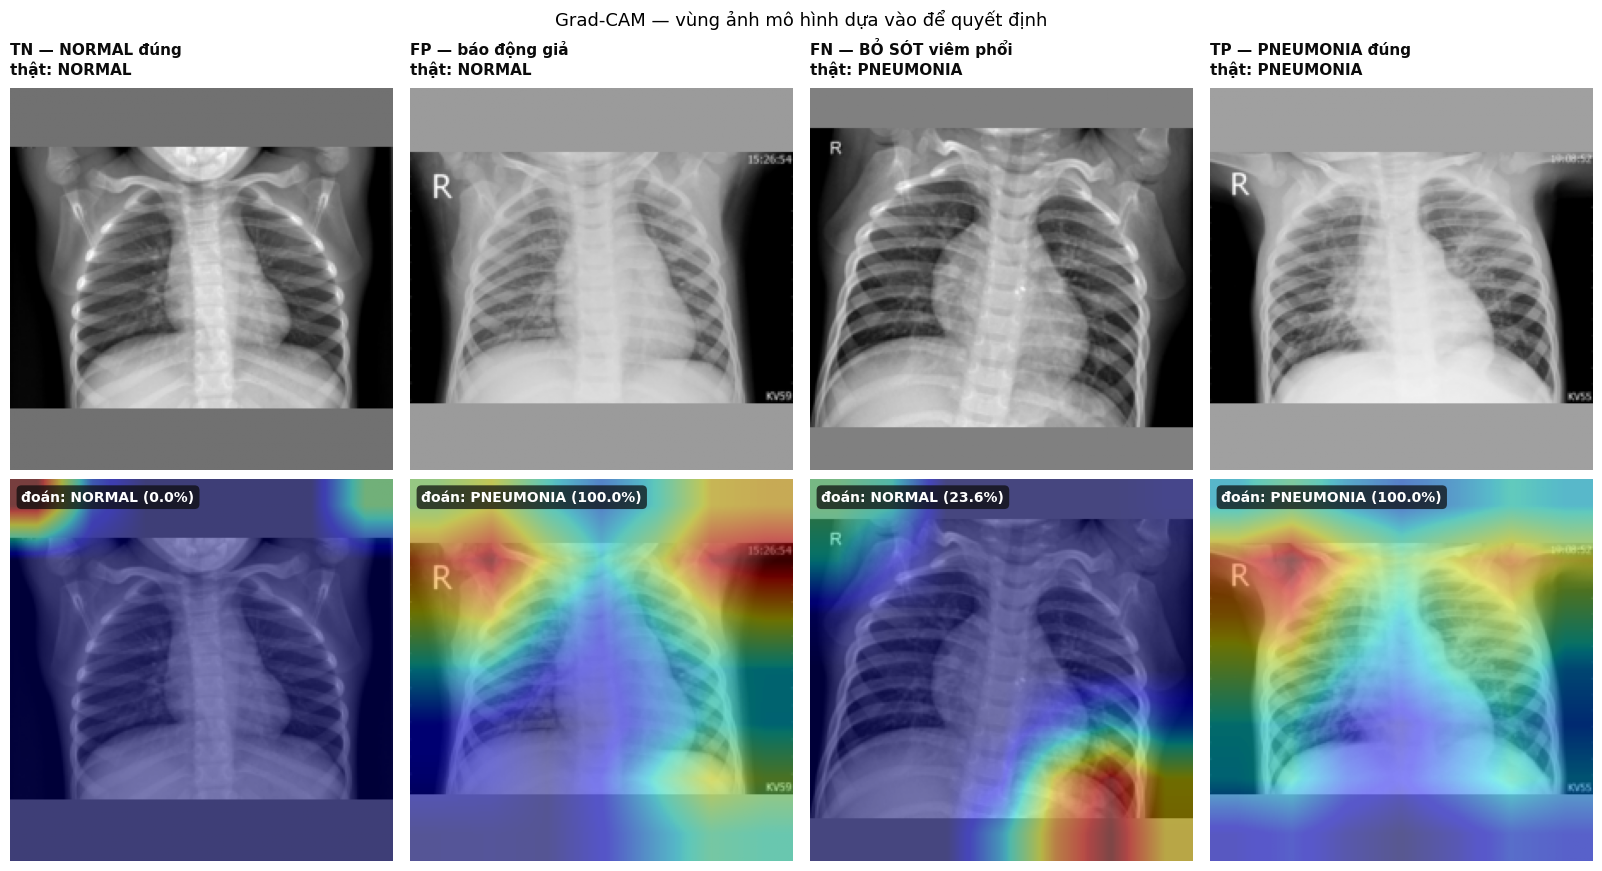

In [27]:
figure, axes = plt.subplots(2, len(picks), figsize=(4.0 * len(picks), 8.6),
                            constrained_layout=True)
axes = np.atleast_2d(axes)

for column, (name, row) in enumerate(picks.items()):
    tensor = model_input(row)
    target = torch.ones(len(tensor), dtype=torch.long, device=DEVICE)
    cams, logits = cam_engine(tensor, target)
    probability = float(row["p_pneumonia"])
    grayscale = denormalize(tensor[0])

    axes[0, column].imshow(grayscale, cmap="gray")
    axes[0, column].set_title(f"{name}\nthật: {CLASSES[row['true']]}",
                              fontsize=11, pad=10)
    axes[1, column].imshow(grayscale, cmap="gray")
    axes[1, column].imshow(cams[0], cmap="jet", alpha=0.45)
    axes[1, column].text(
        0.03, 0.97, f"đoán: {CLASSES[row['pred']]} ({probability:.1%})",
        transform=axes[1, column].transAxes, va="top", ha="left",
        fontsize=10, fontweight="600", color="white",
        bbox=dict(boxstyle="round,pad=0.35", facecolor="#0b0b0b",
                  alpha=0.72, edgecolor="none"))
    for axis in axes[:, column]:
        axis.axis("off")

figure.suptitle("Grad-CAM — vùng ảnh mô hình dựa vào để quyết định", fontsize=13)
plt.show()

## 4.3. Khối lượng nhiệt ở viền ảnh

Quan sát vài tấm bằng mắt dễ dẫn tới kết luận cảm tính. Phép đo dưới đây tính tỉ
lệ khối lượng nhiệt rơi vào **viền hình học 15%** trên mẫu stratify theo TN/FP/FN/TP.
Viền hình học vẫn có thể chứa phổi ngoại vi; đây không phải phép đo lung-vs-artifact.

Mốc diện tích chỉ giúp phát hiện heatmap tập trung bất thường ở biên. Muốn kết
luận ngoài phổi cần segmentation mask thật.

In [28]:
def border_mass_fraction(cam, border=BORDER_FRAC):
    height, width = cam.shape
    margin_y, margin_x = int(height * border), int(width * border)
    interior = cam[margin_y:height - margin_y, margin_x:width - margin_x].sum()
    return float(1.0 - interior / (cam.sum() + 1e-8))


per_cell = 3 if RUN_MODE == "smoke" else 30
sample_parts = []
for (true_label, pred_label), subset in test_rows.groupby(["true", "pred"]):
    sample_parts.append(subset.sample(n=min(per_cell, len(subset)),
                                      random_state=SEED + 10 * true_label + pred_label))
sample = pd.concat(sample_parts, ignore_index=True)
fractions = np.array([border_mass_fraction(cam_engine(model_input(row))[0][0])
                      for _, row in sample.iterrows()])
baseline = 1 - (1 - 2 * BORDER_FRAC) ** 2

print(f"n = {len(fractions)} ảnh test  |  viền ngoài {BORDER_FRAC:.0%}")
print(f"  trung vị       : {np.median(fractions):.1%}")
print(f"  trung bình     : {fractions.mean():.1%}")
print(f"  cao nhất       : {fractions.max():.1%}")
print(f"  mốc ngẫu nhiên : {baseline:.1%}")
print(f"  số ca vượt mốc : {(fractions > baseline).sum()}/{len(fractions)}")

n = 96 ảnh test  |  viền ngoài 15%
  trung vị       : 47.5%
  trung bình     : 45.5%
  cao nhất       : 75.3%
  mốc ngẫu nhiên : 51.0%
  số ca vượt mốc : 28/96


## 4.4. Kiểm tra bằng cách che vùng

Phép thử này che vùng trên ảnh `uint8` **trước normalization**, rồi đo thay đổi có
dấu của logit PNEUMONIA. Nó tránh tạo màu ngoài phân phối như cách chèn một scalar
sau ImageNet normalization.

- Che **viền hình học 15%**
- Che **hình chữ nhật trung tâm**

Hai vùng không tương đương mask phổi/ngoài phổi. Kết quả chỉ dùng để tạo giả
thuyết cho thí nghiệm có lung segmentation sau này.

In [29]:
@torch.no_grad()
def pneumonia_logit(tensor):
    return xai_model(tensor).float()[0, 1].item()


def occluded_input(row, region, border=BORDER_FRAC):
    """Che trên uint8 trước normalization; trả tensor model input."""
    out = torch.from_numpy(IMAGE_CACHE[int(row["cache_index"])]).clone()
    height, width = out.shape
    my, mx = int(height * border), int(width * border)
    fill = torch.median(out.float()).to(out.dtype)
    if region == "border":
        out[:my, :] = fill; out[height - my:, :] = fill
        out[:, :mx] = fill; out[:, width - mx:] = fill
    else:
        out[my:height - my, mx:width - mx] = fill
    return to_model_input(out.unsqueeze(0), XAI_SIZE)


rows = []
for _, row in sample.iterrows():
    tensor = model_input(row)
    base = pneumonia_logit(tensor)
    delta_border = pneumonia_logit(occluded_input(row, "border")) - base
    delta_center = pneumonia_logit(occluded_input(row, "center")) - base
    rows.append({"cell": f"{int(row['true'])}->{int(row['pred'])}",
                 "logit gốc": base,
                 "Δlogit che viền": delta_border,
                 "Δlogit che giữa": delta_center,
                 "|Δ| che viền": abs(delta_border),
                 "|Δ| che giữa": abs(delta_center)})
occlusion = pd.DataFrame(rows)

print(f"n = {len(occlusion)} ảnh test, stratify theo confusion cell\n")
display(occlusion.groupby("cell")[["Δlogit che viền", "Δlogit che giữa",
                                    "|Δ| che viền", "|Δ| che giữa"]].median().round(4))
print("\nDấu âm: che vùng làm giảm logit PNEUMONIA; dấu dương: làm tăng logit.")
print("Không diễn giải viền/giữa thành ngoài-phổi/trong-phổi khi chưa có lung mask.")

cam_engine.close()
del xai_model

n = 96 ảnh test, stratify theo confusion cell



,Δlogit che viền,Δlogit che giữa,|Δ| che viền,|Δ| che giữa
cell,,,,
0->0,5.3522,4.8591,5.3522,4.8591
0->1,0.1633,2.6165,0.6973,2.6165
1->0,2.5506,3.4608,2.5506,3.4608
1->1,0.5215,-0.4976,0.7818,0.9940



Dấu âm: che vùng làm giảm logit PNEUMONIA; dấu dương: làm tăng logit.
Không diễn giải viền/giữa thành ngoài-phổi/trong-phổi khi chưa có lung mask.


---

# 5. Kết luận và hạn chế

## Cách gọi tên kết quả

Khi trích dẫn số từ báo cáo này, ghi kèm nhãn để người đọc biết nó thuộc loại nào:

| Nhãn | Ý nghĩa | Có trong báo cáo này |
|---|---|---|
| `smoke` | Kiểm tra kỹ thuật, không dùng để báo cáo | khi `RUN_MODE=smoke` |
| `reproduced` | Full run theo cấu hình đã ghi | chỉ khi `RUN_MODE=full` |
| `filename_grouped` | Chia chống rò rỉ theo group suy từ filename | ✅ mọi fold |
| `external` | Chạy trên nguồn dữ liệu khác | ❌ chưa có |
| `paper_reported` | Số do tài liệu gốc công bố | không áp dụng |

Không dùng các từ "trustworthy", "clinical-ready", "radiologist-level" khi chưa
có kiểm chứng lâm sàng bên ngoài.

## Đã làm được

- Pipeline chạy đầu-cuối, xử lý được các bất thường của bộ dữ liệu: hai kiểu
  đường dẫn mount, cây thư mục lồng trùng, file sidecar `._*`.
- Kiểm tra chất lượng dữ liệu có số liệu và tái chạy được.
- Chia theo filename-derived group và hash, xác nhận không overlap giữa split.
- Cross-validation nhiều fold, báo khoảng dao động thay vì một con số đơn lẻ.
- **So sánh ba kiến trúc và hai cách xử lý mất cân bằng** dưới cùng giao thức.
- Chọn checkpoint bằng validation AUC, chọn cấu hình bằng OOF group AUC.
- Chỉ đánh giá official test sau khi khóa cấu hình.
- Tune riêng threshold mức ảnh và mức filename-derived group.
- Letterbox giữ tỉ lệ khung thay vì kéo méo ảnh thành hình vuông.
- XAI dùng mẫu stratify và occlusion trước normalization; không gọi viền/giữa là
  ngoài-phổi/trong-phổi khi chưa có lung mask.
- Seed đầy đủ gồm cả DataLoader; ghi lại phiên bản thư viện vào `environment.json`.

## Hạn chế

- **Official test đã từng được xem trong notebook v2.** Kết quả rerun vẫn cần
  external/fresh holdout để có ước lượng cuối không thiên lệch.
- Group chỉ suy từ filename, không phải patient metadata chính thức.
- Cùng OOF được dùng cho chọn cấu hình và tune threshold; triển khai thật cần
  calibration set độc lập hoặc nested/cross-fitted calibration.
- **Các fold đổi đồng thời cả cách chia lẫn seed**, nên `± std` là tổng của hai
  nguồn dao động, chưa tách riêng được. Muốn tách thì giữ nguyên một fold và đổi
  seed.
- Raw softmax từ weighted loss chưa phải xác suất lâm sàng đã calibration.
- Seed không đảm bảo bitwise-identical giữa CUDA, MPS và CPU.
- **Precision đo trên tập test có 62,5% ca bệnh**, cao hơn thực tế phòng khám, nên
  con số này không chuyển sang môi trường triển khai được.
- **Dữ liệu từ một trung tâm, chỉ gồm bệnh nhi 1–5 tuổi.** Không có cơ sở suy rộng
  sang người lớn hay cơ sở y tế khác nếu chưa kiểm chứng trên dữ liệu ngoài.
- **Nhãn nhị phân** không mô tả các bất thường khác có thể có trong nhóm bình thường.

## Hướng tiếp theo

1. Kiểm chứng trên một bộ dữ liệu ngoài trước khi nói tới khả năng khái quát hoá.
2. Bổ sung lung segmentation mask rồi chạy lại XAI/occlusion đúng vùng giải phẫu.
3. Calibration độc lập và báo Brier score, ECE, calibration curve.
4. Hard-negative mining chỉ từ train/OOF, tuyệt đối không lấy từ official test.
5. Chạy nhiều seed và patient/group bootstrap confidence interval.

## Tệp xuất ra

| Tệp | Nội dung |
|---|---|
| `train_log.txt` | Nhật ký huấn luyện đầy đủ |
| `results_oof_validation.csv` | So sánh cấu hình chỉ từ validation |
| `results_official_test.csv` | Kết quả test của duy nhất cấu hình đã khóa |
| `predictions_official_test_images.csv` | Xác suất test mức ảnh để audit |
| `validation_predictions_*` | OOF/holdout prediction từng fold |
| `manifest_fold*.csv` | Danh sách ảnh chính xác của từng fold |
| `environment.json` | Phiên bản thư viện, device, mode, seed |
| `*_fold*.pth` | Trọng số tốt nhất của từng thí nghiệm × fold |

Đính kèm `manifest_fold*.csv` và `environment.json` khi nộp để người đọc truy
ngược được đúng danh sách ảnh và đúng môi trường đứng sau mỗi con số.